In [ ]:
import sqlite3
import pandas as pd
import re

df=pd.read_csv("/content/Sample - Superstore.csv",encoding="latin1")

#LEADING AND TRAILING SPACES
for col in df.select_dtypes(include= "object"):
  df[col] = df[col].str.strip()


#ORDER DATE
def date_clean(dates):
  dates = pd.to_datetime(dates,format="mixed")
  return dates
df["Order Date"] = df["Order Date"].apply(date_clean)


#SHIP DATE
df["Ship Date"] = df["Ship Date"].apply(date_clean)


#PROFIT
df["Profit"] = df['Profit'].round()


#DISCOUNT
df["Discount"] = df["Discount"]*100
df["Discount"] = df["Discount"].astype(int)


#SALES
df["Sales"] = df["Sales"].round(0)


#SHIP DAYS COLUMN
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days


#Rank for finding diff in sales and profit
# def find_rank_difference(column):

#     sales_rank = (
#         df.groupby(column)["Sales"]
#         .sum()
#         .rank(
#             ascending=False,
#             method="dense"
#         )
#     )


#     profit_rank = (
#         df.groupby(column)["Profit"]
#         .sum()
#         .rank(
#             ascending=False,
#             method="dense"
#         )
#     )


#     result = pd.DataFrame({

#         "Sales Rank":sales_rank,
#         "Profit Rank":profit_rank

#     })


#     result["Rank Difference"] = abs(

#         result["Sales Rank"] -
#         result["Profit Rank"]

#     )


#     return result.sort_values(
#         by="Rank Difference",
#         ascending=False
#     )


#SQL DATABASE
conn = sqlite3.connect("SupurstoreD.db")
df.to_sql("Superstore",conn,if_exists="replace")




print(df.head(10))

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
5       6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
6       7  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
7       8  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
8       9  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
9      10  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

     Customer Name    Segment        Country             City  ... Region  \
0      Claire Gute   Consumer  United States        H

In [ ]:
query = """select Segment, "Ship Mode" ,Sales, Quantity , Profit
from Superstore
"""

print(pd.read_sql(query,conn))

        Segment       Ship Mode  Sales  Quantity  Profit
0      Consumer    Second Class  262.0         2    42.0
1      Consumer    Second Class  732.0         3   220.0
2     Corporate    Second Class   15.0         2     7.0
3      Consumer  Standard Class  958.0         5  -383.0
4      Consumer  Standard Class   22.0         2     3.0
...         ...             ...    ...       ...     ...
9989   Consumer    Second Class   25.0         3     4.0
9990   Consumer  Standard Class   92.0         2    16.0
9991   Consumer  Standard Class  259.0         2    19.0
9992   Consumer  Standard Class   30.0         4    13.0
9993   Consumer    Second Class  243.0         2    73.0

[9994 rows x 5 columns]


In [ ]:
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Total Products: {df['Product ID'].nunique():,}")
print(f"Average Order Value: ${df['Sales'].mean():,.2f}")

Total Sales: $2,297,340.00
Total Profit: $286,340.00
Total Orders: 5,009
Total Customers: 793
Total Products: 1,862
Average Order Value: $229.87


In [ ]:
query = """SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore;
"""

print(pd.read_sql(query,conn))

   Total_Sales
0    2297340.0


In [ ]:
query = """SELECT
    ROUND(SUM(Profit), 2) AS Total_Sales
FROM Superstore;
"""

print(pd.read_sql(query,conn))

   Total_Sales
0     286340.0


In [ ]:
query = """SELECT
    COUNT(DISTINCT "Order ID") AS Total_Orders
FROM Superstore;
"""

print(pd.read_sql(query,conn))

   Total_Orders
0          5009


In [ ]:
query = """SELECT
    COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM Superstore
"""

print(pd.read_sql(query,conn))

   Total_Customers
0              793


In [ ]:
query = """SELECT
    COUNT(DISTINCT "Product ID") AS Total_Products
FROM Superstore;
"""

print(pd.read_sql(query,conn))

   Total_Products
0            1862


In [ ]:
query = """SELECT
    (Avg ("Sales")) AS Avg_order_value
FROM Superstore;
"""

print(pd.read_sql(query,conn))

   Avg_order_value
0       229.871923


In [ ]:
query = """SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore
GROUP BY Category
ORDER BY Total_Sales DESC;"""               #furniture mai why more diff

print(pd.read_sql(query,conn))

          Category  Total_Sales
0       Technology     836219.0
1        Furniture     742003.0
2  Office Supplies     719118.0


In [ ]:
query = """SELECT
    Category,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY Category
ORDER BY Total_Profit DESC;"""

print(pd.read_sql(query,conn))

          Category  Total_Profit
0       Technology      145423.0
1  Office Supplies      122473.0
2        Furniture       18444.0


In [ ]:
query = """SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore
GROUP BY Region
ORDER BY Total_Sales DESC;"""

print(pd.read_sql(query,conn))

    Region  Total_Sales
0     West     725511.0
1     East     678828.0
2  Central     501253.0
3    South     391748.0


In [ ]:
query = """SELECT
    Region,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY Region
ORDER BY Total_Profit DESC;"""             # south central more diff

print(pd.read_sql(query,conn))

    Region  Total_Profit
0     West      108383.0
1     East       91518.0
2    South       46721.0
3  Central       39718.0


In [ ]:
query = """SELECT
    State,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore
GROUP BY State
ORDER BY Total_Sales DESC;"""                    #texas going more down why

print(pd.read_sql(query,conn))

                   State  Total_Sales
0             California     457728.0
1               New York     310911.0
2                  Texas     170187.0
3             Washington     138656.0
4           Pennsylvania     116522.0
5                Florida      89479.0
6               Illinois      80162.0
7                   Ohio      78253.0
8               Michigan      76280.0
9               Virginia      70641.0
10        North Carolina      55604.0
11               Indiana      53549.0
12               Georgia      49102.0
13              Kentucky      36598.0
14            New Jersey      35763.0
15               Arizona      35283.0
16             Wisconsin      32124.0
17              Colorado      32110.0
18             Tennessee      30662.0
19             Minnesota      29865.0
20         Massachusetts      28639.0
21              Delaware      27451.0
22              Maryland      23706.0
23          Rhode Island      22629.0
24              Missouri      22207.0
25          

In [ ]:
query = """SELECT
    State,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY State
ORDER BY Total_Profit DESC;"""

print(pd.read_sql(query,conn))

                   State  Total_Profit
0             California       76367.0
1               New York       74018.0
2             Washington       33389.0
3               Michigan       24458.0
4               Virginia       18600.0
5                Indiana       18382.0
6                Georgia       16247.0
7               Kentucky       11202.0
8              Minnesota       10828.0
9               Delaware        9979.0
10            New Jersey        9771.0
11             Wisconsin        8400.0
12          Rhode Island        7286.0
13              Maryland        7032.0
14         Massachusetts        6782.0
15              Missouri        6435.0
16               Alabama        5785.0
17              Oklahoma        4852.0
18              Arkansas        4006.0
19           Connecticut        3510.0
20                Nevada        3316.0
21           Mississippi        3172.0
22                  Utah        2546.0
23               Vermont        2247.0
24             Louisiana 

In [ ]:
query = """SELECT
    City,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore
GROUP BY City
ORDER BY Total_Sales DESC
Limit 30;"""

print(pd.read_sql(query,conn))

             City  Total_Sales
0   New York City     256394.0
1     Los Angeles     175856.0
2         Seattle     119552.0
3   San Francisco     112689.0
4    Philadelphia     109085.0
5         Houston      64504.0
6         Chicago      48540.0
7       San Diego      47521.0
8    Jacksonville      44712.0
9     Springfield      43052.0
10        Detroit      42452.0
11       Columbus      38698.0
12         Newark      28575.0
13       Columbia      25288.0
14      Lafayette      25035.0
15        Jackson      24965.0
16    San Antonio      21848.0
17     Burlington      21668.0
18      Arlington      20218.0
19         Dallas      20129.0
20       Lakewood      18190.0
21       Richmond      18137.0
22      Henderson      17550.0
23        Atlanta      17200.0
24    Minneapolis      16871.0
25     Providence      15981.0
26      Charlotte      13692.0
27     Long Beach      13460.0
28     Louisville      12349.0
29         Denver      12199.0


In [ ]:
query = """SELECT
    City,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY City
ORDER BY Total_Profit DESC
Limit 30;"""

print(pd.read_sql(query,conn))

               City  Total_Profit
0     New York City       62018.0
1       Los Angeles       30438.0
2           Seattle       29144.0
3     San Francisco       17494.0
4           Detroit       13178.0
5         Lafayette       10016.0
6           Jackson        7578.0
7           Atlanta        6994.0
8       Minneapolis        6824.0
9         San Diego        6378.0
10      Springfield        6198.0
11         Columbus        5899.0
12           Newark        5794.0
13         Columbia        5604.0
14         Richmond        5565.0
15       Providence        5507.0
16        Henderson        4913.0
17        Arlington        4170.0
18         Lakewood        3232.0
19        Milwaukee        2794.0
20          Yonkers        2768.0
21     Indianapolis        2741.0
22          Roswell        2426.0
23         Lawrence        2380.0
24          Midland        2293.0
25  North Las Vegas        2247.0
26           Mobile        2175.0
27         Florence        2171.0
28       Long 

In [ ]:
query = """SELECT
    "Customer Name",
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 50;"""

print(pd.read_sql(query,conn))


           Customer Name  Total_Sales
0            Sean Miller      25042.0
1           Tamara Chand      19050.0
2           Raymond Buch      15117.0
3           Tom Ashbrook      14596.0
4          Adrian Barton      14476.0
5           Ken Lonsdale      14175.0
6           Sanjit Chand      14145.0
7           Hunter Lopez      12875.0
8           Sanjit Engle      12209.0
9     Christopher Conant      12128.0
10          Todd Sumrall      11891.0
11             Greg Tran      11821.0
12          Becky Martin      11791.0
13           Seth Vernon      11472.0
14       Caroline Jumper      11165.0
15           Clay Ludtke      10881.0
16         Maria Etezadi      10665.0
17        Karen Ferguson      10606.0
18          Bill Shonely      10502.0
19          Edward Hooks      10313.0
20              John Lee       9799.0
21        Grant Thornton       9351.0
22       Helen Wasserman       9299.0
23      Tom Boeckenhauer       9134.0
24          Peter Fuller       9065.0
25  Christop

In [ ]:
query = """SELECT
    "Customer Name",
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY "Customer Name"
ORDER BY Total_Profit asc
LIMIT 50"""

print(pd.read_sql(query,conn))            #7 sean miller ken and keihth dokins make a function to check if more diff is there python qill give name

         Customer Name  Total_Profit
0        Cindy Stewart       -6625.0
1       Grant Thornton       -4109.0
2          Luke Foster       -3583.0
3       Sharelle Roach       -3336.0
4        Henry Goldwyn       -2797.0
5          Nathan Cano       -2204.0
6         Sean Braxton       -2082.0
7          Sean Miller       -1981.0
8       Christine Phan       -1852.0
9     Natalie Fritzler       -1697.0
10        Becky Martin       -1660.0
11     Tracy Blumstein       -1601.0
12        Dan Campbell       -1440.0
13        David Bremer       -1422.0
14        Rose O'Brian       -1263.0
15        Tom Prescott       -1088.0
16    Zuschuss Carroll       -1032.0
17    Victoria Pisteka       -1019.0
18     Shahid Shariari       -1012.0
19         Olvera Toch        -924.0
20     Victoria Wilson        -873.0
21        Joseph Airdo        -819.0
22        Paul Knutson        -799.0
23         Jim Radford        -785.0
24        Skye Norling        -717.0
25      Barry Gonzalez        -711.0
2

In [ ]:
query = """
SELECT
    "Product Name" , "Product ID",
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM Superstore
GROUP BY "Product Name", "Product ID"
ORDER BY Total_Sales DESC
LIMIT 50;
"""

Total_Sales = pd.read_sql_query(query, conn)
display(Total_Sales)

,Product Name,Product ID,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,TEC-CO-10004722,61600.0
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,OFF-BI-10003527,27454.0
2,Cisco TelePresence System EX90 Videoconferenci...,TEC-MA-10002412,22638.0
3,HON 5400 Series Task Chairs for Big and Tall,FUR-CH-10002024,21870.0
4,GBC DocuBind TL300 Electric Binding System,OFF-BI-10001359,19824.0
5,GBC Ibimaster 500 Manual ProClick Binding System,OFF-BI-10000545,19026.0
6,Hewlett Packard LaserJet 3310 Copier,TEC-CO-10001449,18840.0
7,HP Designjet T520 Inkjet Large Format Printer ...,TEC-MA-10001127,18375.0
8,GBC DocuBind P400 Electric Binding System,OFF-BI-10004995,17965.0
9,High Speed Automatic Electric Letter Opener,OFF-SU-10000151,17031.0


In [ ]:
query = """
SELECT
    "Product Name" , "Product ID",
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY "Product Name", "Product ID"
ORDER BY Total_Profit desc
LIMIT 50;
"""

Total_Sales = pd.read_sql_query(query, conn)
display(Total_Sales)

,Product Name,Product ID,Total_Profit
0,Canon imageCLASS 2200 Advanced Copier,TEC-CO-10004722,25200.0
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,OFF-BI-10003527,7751.0
2,Hewlett Packard LaserJet 3310 Copier,TEC-CO-10001449,6984.0
3,Canon PC1060 Personal Laser Copier,TEC-CO-10003763,4571.0
4,HP Designjet T520 Inkjet Large Format Printer ...,TEC-MA-10001127,4095.0
5,Ativa V4110MDD Micro-Cut Shredder,TEC-MA-10003979,3773.0
6,"3D Systems Cube Printer, 2nd Generation, Magenta",TEC-MA-10001047,3718.0
7,Plantronics Savi W720 Multi-Device Wireless He...,TEC-AC-10002049,3697.0
8,Ibico EPK-21 Electric Binding System,OFF-BI-10001120,3345.0
9,Zebra ZM400 Thermal Label Printer,TEC-MA-10000045,3344.0


In [ ]:
query = """
SELECT
    Segment,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM superstore
GROUP BY Segment
ORDER BY Total_Sales DESC;
"""

Total_Sales = pd.read_sql_query(query, conn)
display(Total_Sales)

,Segment,Total_Sales
0,Consumer,1161489.0
1,Corporate,706180.0
2,Home Office,429671.0


In [ ]:
query = """
SELECT
    Segment,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Segment
ORDER BY Total_Profit DESC;
"""

Total_Sales = pd.read_sql_query(query, conn)
display(Total_Sales)

,Segment,Total_Profit
0,Consumer,134108.0
1,Corporate,91964.0
2,Home Office,60268.0


In [ ]:
query = """
SELECT
    Segment,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM superstore
GROUP BY Segment
ORDER BY Total_Sales DESC;
"""

Total_Sales = pd.read_sql_query(query, conn)
display(Total_Sales)

,Segment,Total_Sales
0,Consumer,1161489.0
1,Corporate,706180.0
2,Home Office,429671.0


In [ ]:
query = """
SELECT
    "Segment",
   ROUND(SUM(Profit*100.0)/ SUM(Sales), 2) AS Profit_Region
FROM superstore
GROUP BY "Segment";
"""

ship_mode_sales = pd.read_sql_query(query, conn)
display(ship_mode_sales)

,Segment,Profit_Region
0,Consumer,11.55
1,Corporate,13.02
2,Home Office,14.03


In [ ]:
query = """
SELECT
    "Ship Mode",
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY "Ship Mode"
ORDER BY Total_Profit DESC;
"""

ship_mode_sales = pd.read_sql_query(query, conn)
display(ship_mode_sales)

,Ship Mode,Total_Profit
0,Standard Class,164058.0
1,Second Class,57430.0
2,First Class,48959.0
3,Same Day,15893.0


In [ ]:
query = """SELECT "Ship Mode",
    ROUND(Avg ("Ship Days"),2) as Avg_Ship_days
FROM Superstore
group by "Ship Mode" """

print(pd.read_sql(query,conn))

        Ship Mode  Avg_Ship_days
0     First Class           2.18
1        Same Day           0.04
2    Second Class           3.24
3  Standard Class           5.01


In [ ]:
query = """SELECT Region,
    ROUND(Avg ("Ship Days"),2) as Avg_Ship_days
FROM Superstore
group by "Region" """

print(pd.read_sql(query,conn))

    Region  Avg_Ship_days
0  Central           4.06
1     East           3.91
2    South           3.96
3     West           3.93


In [ ]:
query = """SELECT "Ship Mode", ROUND(Avg ("Ship Days"),2) as Avg_Ship_days
FROM Superstore
where City like "%Washington%"
group by "Ship Mode" """

print(pd.read_sql(query,conn))

        Ship Mode  Avg_Ship_days
0    Second Class            5.0
1  Standard Class            6.0


In [ ]:
query = """ SELECT
    Discount,
    ROUND(AVG(Sales),2) AS Avg_Sales,
    ROUND(AVG(Profit),2) AS Avg_Profit
FROM Superstore
GROUP BY Discount
ORDER BY Discount;"""

print(pd.read_sql(query,conn))   # 60-80 disc nikaldena cuz no slaes no profit

    Discount  Avg_Sales  Avg_Profit
0          0     226.76       66.89
1         10     578.46       96.01
2         15     530.00       27.23
3         20     209.09       24.70
4         30     454.67      -45.65
5         32     536.70      -88.52
6         40     565.18     -111.90
7         45     498.64     -226.64
8         50     892.61     -310.73
9         60      48.18      -43.07
10        70      97.19      -95.91
11        80      56.54     -101.82


In [ ]:
query = """ SELECT
    strftime('%Y-%m', "Order Date") AS Month,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM Superstore
GROUP BY Month
ORDER BY Month;"""

print(pd.read_sql(query,conn))

      Month  Total_Sales
0   2014-01      14238.0
1   2014-02       4518.0
2   2014-03      55688.0
3   2014-04      28294.0
4   2014-05      23648.0
5   2014-06      34598.0
6   2014-07      33947.0
7   2014-08      27908.0
8   2014-09      81786.0
9   2014-10      31448.0
10  2014-11      78633.0
11  2014-12      69545.0
12  2015-01      18172.0
13  2015-02      11954.0
14  2015-03      38732.0
15  2015-04      34197.0
16  2015-05      30136.0
17  2015-06      24800.0
18  2015-07      28765.0
19  2015-08      36899.0
20  2015-09      64601.0
21  2015-10      31406.0
22  2015-11      75979.0
23  2015-12      74916.0
24  2016-01      18548.0
25  2016-02      22979.0
26  2016-03      51716.0
27  2016-04      38757.0
28  2016-05      56992.0
29  2016-06      40352.0
30  2016-07      39262.0
31  2016-08      31119.0
32  2016-09      73414.0
33  2016-10      59692.0
34  2016-11      79413.0
35  2016-12      97008.0
36  2017-01      43976.0
37  2017-02      20306.0
38  2017-03      58880.0


In [ ]:
query = """ SELECT
    strftime("%Y", "Order Date") AS Year,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM Superstore
GROUP BY Year
ORDER BY Total_Sales desc;"""

print(pd.read_sql(query,conn))

   Year  Total_Sales
0  2017     733280.0
1  2016     609252.0
2  2014     484251.0
3  2015     470557.0


In [ ]:
query ="""SELECT
    "Sub-Category",
    ROUND(SUM(Profit),2) AS Total_Profit , ROUND(SUM(Sales),2) AS Total_Sales
FROM Superstore
GROUP BY "Sub-Category"
ORDER BY Total_Profit DESC;"""

print(pd.read_sql(query,conn))

   Sub-Category  Total_Profit  Total_Sales
0       Copiers       55618.0     149530.0
1        Phones       44490.0     330047.0
2   Accessories       41928.0     167400.0
3         Paper       34053.0      78475.0
4       Binders       30200.0     203425.0
5        Chairs       26586.0     328453.0
6       Storage       21280.0     223860.0
7    Appliances       18132.0     107537.0
8   Furnishings       13070.0      91704.0
9     Envelopes        6956.0      16477.0
10          Art        6529.0      27136.0
11       Labels        5558.0      12505.0
12     Machines        3387.0     189242.0
13    Fasteners         952.0       3024.0
14     Supplies       -1187.0      46679.0
15    Bookcases       -3479.0     114879.0
16       Tables      -17733.0     206967.0


In [ ]:
query ="""SELECT
    "Sub-Category",
    ROUND(SUM(Profit),2) AS Total_Profit , ROUND(SUM(Sales),2) AS Total_Sales
FROM Superstore
GROUP BY "Sub-Category"
ORDER BY Total_Sales asc;"""

print(pd.read_sql(query,conn))

   Sub-Category  Total_Profit  Total_Sales
0     Fasteners         952.0       3024.0
1        Labels        5558.0      12505.0
2     Envelopes        6956.0      16477.0
3           Art        6529.0      27136.0
4      Supplies       -1187.0      46679.0
5         Paper       34053.0      78475.0
6   Furnishings       13070.0      91704.0
7    Appliances       18132.0     107537.0
8     Bookcases       -3479.0     114879.0
9       Copiers       55618.0     149530.0
10  Accessories       41928.0     167400.0
11     Machines        3387.0     189242.0
12      Binders       30200.0     203425.0
13       Tables      -17733.0     206967.0
14      Storage       21280.0     223860.0
15       Chairs       26586.0     328453.0
16       Phones       44490.0     330047.0


In [ ]:
#MONTHLY SALES
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

monthly_sales.head(10)

# monthly_sales["Order Date"].head()
# monthly_sales["Sales"].head()


,Order Date,Sales
0,2014-01,14238.0
1,2014-02,4518.0
2,2014-03,55688.0
3,2014-04,28294.0
4,2014-05,23648.0
5,2014-06,34598.0
6,2014-07,33947.0
7,2014-08,27908.0
8,2014-09,81786.0
9,2014-10,31448.0


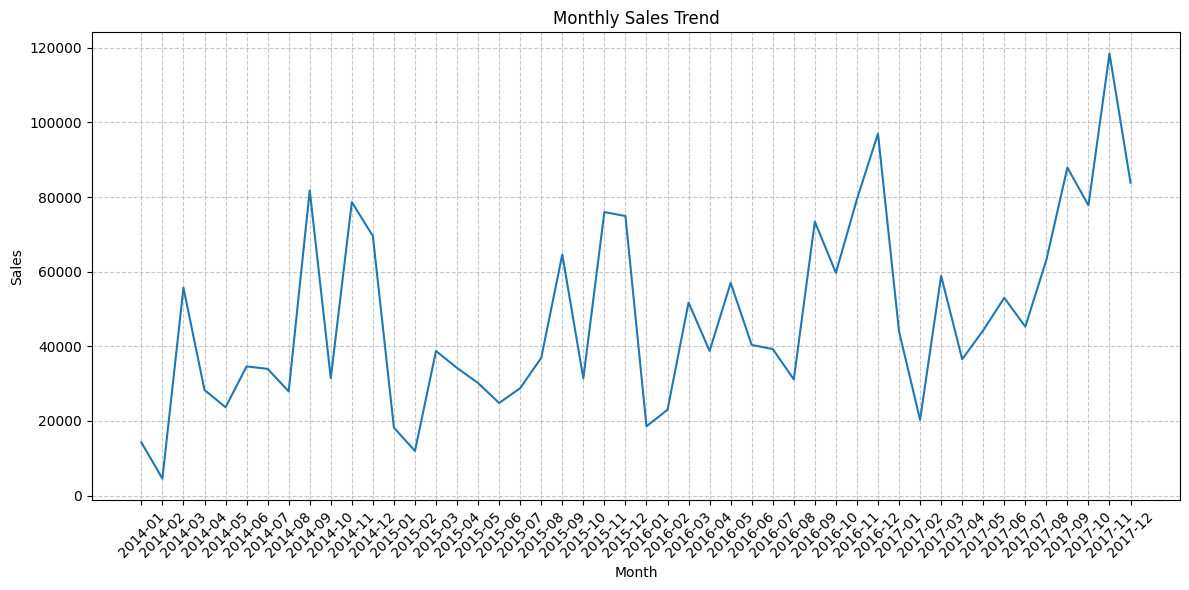

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


March August Nov Dec sales are peak so we have to maintain our sales at the peak by that time and this can be done by applying 10% discount as already these are highest peak hitting months so by applying 10% disc these sales can be maintained while achieving more profit as well

As for the months such as jan feb where theres lowest peak in sales we can up the sales by applying 50% discount so that the drop is not too heavy on the business to recover

In [ ]:
#Monthly Profit
monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
      .sum()
      .reset_index()
)

monthly_profit["Order Date"] = monthly_profit["Order Date"].astype(str)

monthly_profit.head(10)


,Order Date,Profit
0,2014-01,2446.0
1,2014-02,859.0
2,2014-03,495.0
3,2014-04,3490.0
4,2014-05,2736.0
5,2014-06,4974.0
6,2014-07,-840.0
7,2014-08,5319.0
8,2014-09,8314.0
9,2014-10,3446.0


In [ ]:
SubCategory_profit = (
    df.groupby(df["Sub-Category"])[["Profit","Sales"]].sum())

SubCategory_profit.head(17)

,Profit,Sales
Sub-Category,,
Accessories,41928.0,167400.0
Appliances,18132.0,107537.0
Art,6529.0,27136.0
Binders,30200.0,203425.0
Bookcases,-3479.0,114879.0
Chairs,26586.0,328453.0
Copiers,55618.0,149530.0
Envelopes,6956.0,16477.0
Fasteners,952.0,3024.0


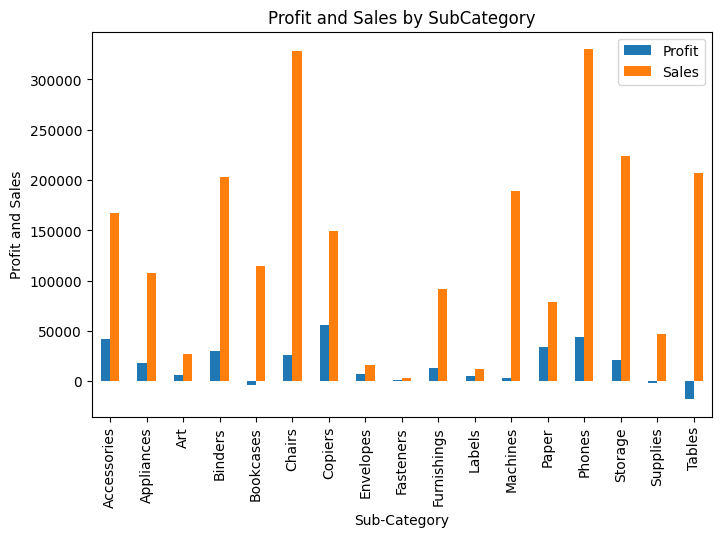

In [ ]:
SubCategory_profit.plot(
    kind="bar",
    figsize=(8,5))


plt.title("Profit and Sales by SubCategory")
plt.ylabel("Profit and Sales")
plt.xlabel("Sub-Category")
plt.xticks(rotation = 90)
plt.show()

,Profit,Sales
State,,
California,76367.0,457728.0
New York,74018.0,310911.0
Washington,33389.0,138656.0
Michigan,24458.0,76280.0
Virginia,18600.0,70641.0


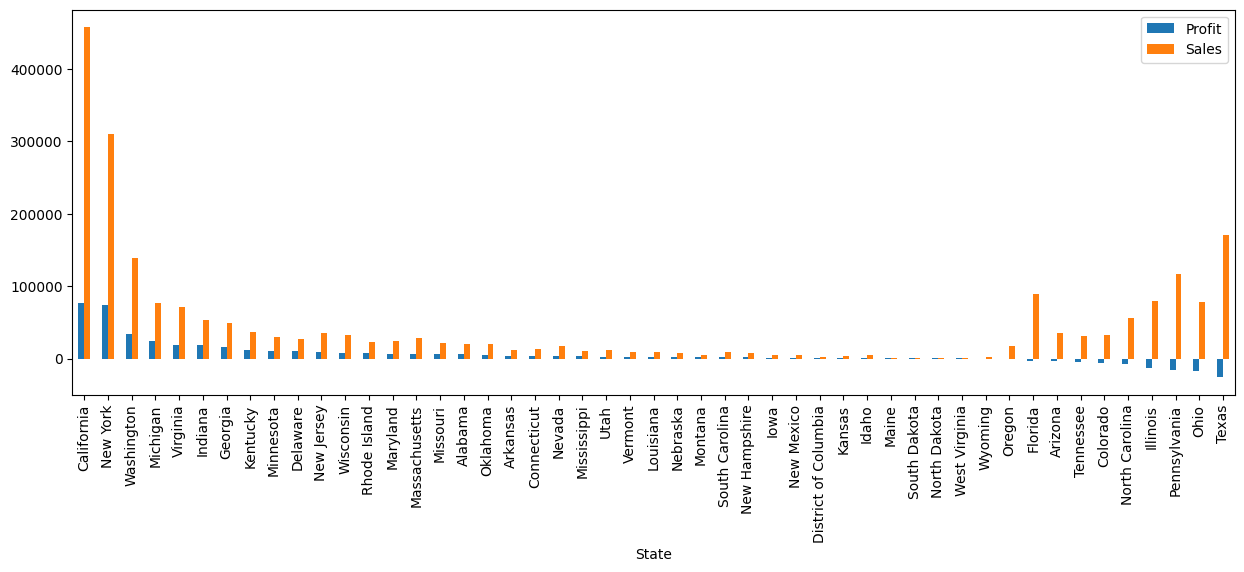

In [ ]:
State = (
  df.groupby("State")[["Profit","Sales"]].sum().sort_values(by="Profit",ascending=False))
State.plot(kind = "bar", figsize = (15,5))

State.head()


,Sales,Profit
Region,,
West,725511.0,108383.0
East,678828.0,91518.0
South,391748.0,46721.0
Central,501253.0,39718.0


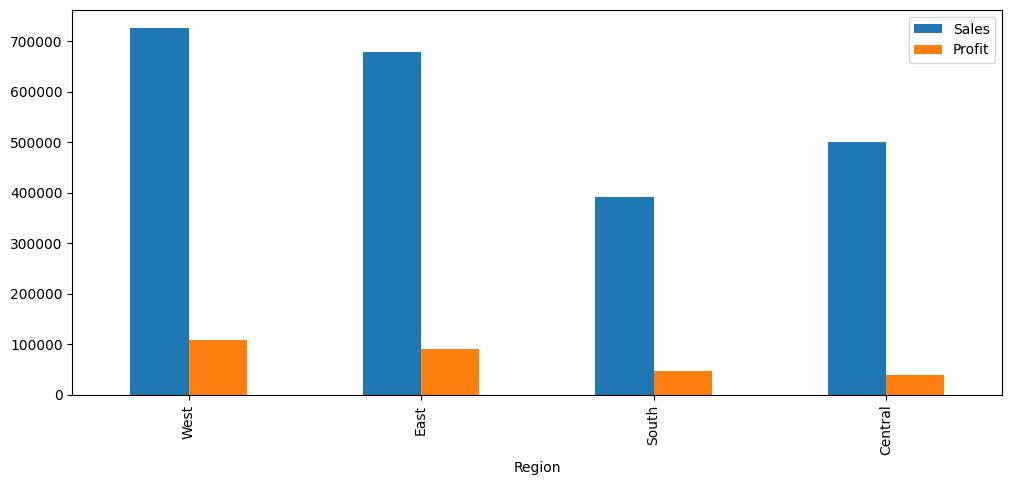

In [ ]:
RegionPS = (
    df.groupby("Region")[["Sales","Profit"]].sum().sort_values(by="Profit",ascending=False)
)

RegionPS.plot(kind = "bar",figsize=(12,5))
RegionPS.head()





In [ ]:
states_by_region = (
    df.groupby("Region")["State"]
    .unique()
)

print(states_by_region.head(50))

Region
Central    [Texas, Wisconsin, Nebraska, Illinois, Minneso...
East       [Pennsylvania, Delaware, New York, Ohio, Conne...
South      [Kentucky, Florida, North Carolina, Virginia, ...
West       [California, Washington, Utah, Arizona, Oregon...
Name: State, dtype: object


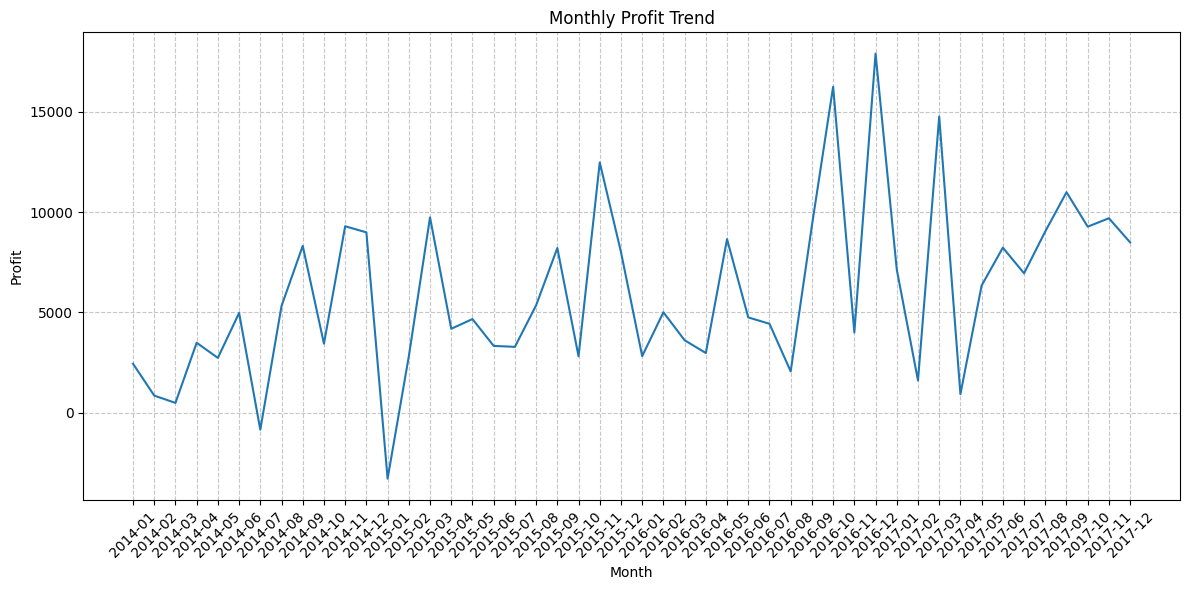

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_profit["Order Date"],
    monthly_profit["Profit"]
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

2014-7 and 2015-1 had negative profit

2015 lowest profit

2016 and 2017 have a drop in profit why

In [ ]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_category.head()


,Sales
Category,
Technology,836219.0
Furniture,742003.0
Office Supplies,719118.0


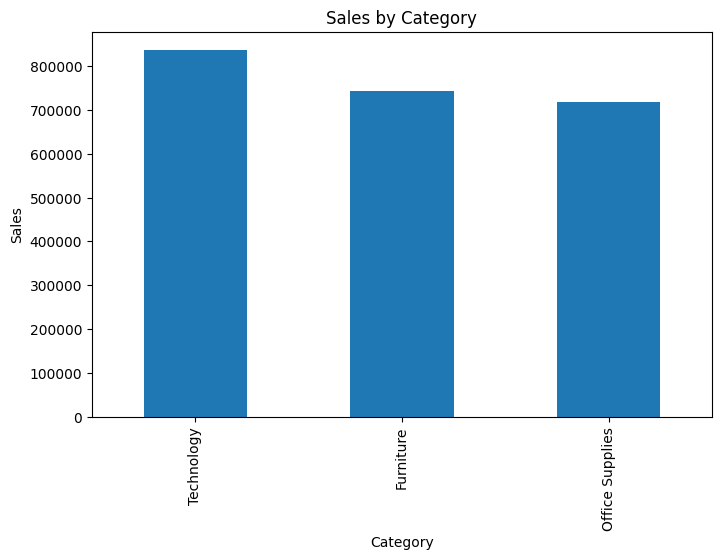

In [ ]:
sales_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

In [ ]:
#TO DOOO

furniture = df[df["Category"] == "Furniture"]

monthly_sales_f = (
    furniture.groupby(furniture["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales_f["Order Date"] = monthly_sales_f["Order Date"].astype(str)

monthly_sales_f.head(10)
#----------------------------------------------------------------------------

,Order Date,Sales
0,2014-01,6243.0
1,2014-02,1840.0
2,2014-03,14575.0
3,2014-04,7944.0
4,2014-05,6911.0
5,2014-06,13206.0
6,2014-07,10820.0
7,2014-08,7317.0
8,2014-09,23819.0
9,2014-10,12304.0


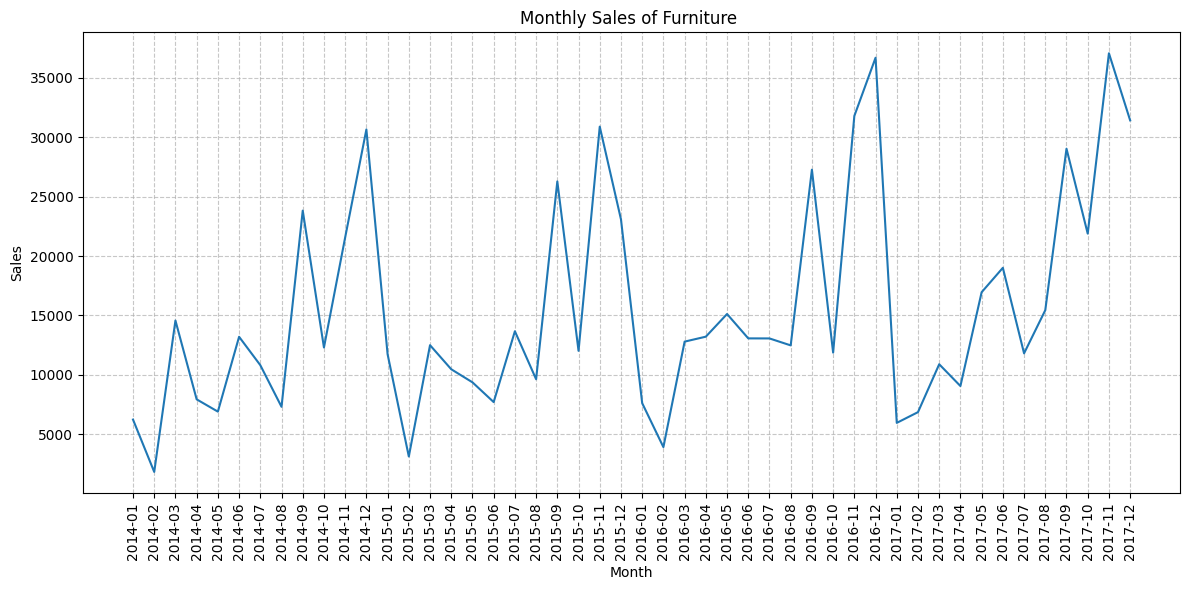

In [ ]:
plt.figure(figsize = (12,6))

plt.plot(
    monthly_sales_f["Order Date"],
    monthly_sales_f["Sales"]
)

plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Monthly Sales of Furniture ")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


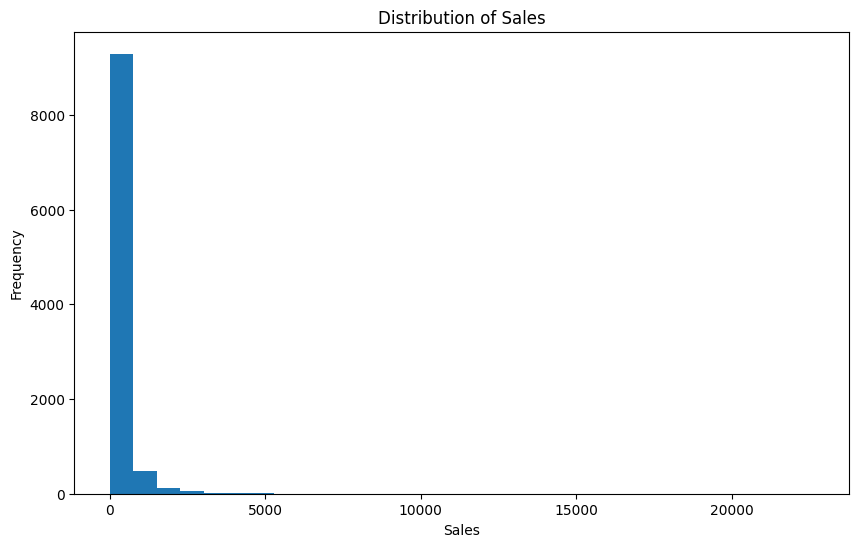

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Sales"],
    bins=30
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

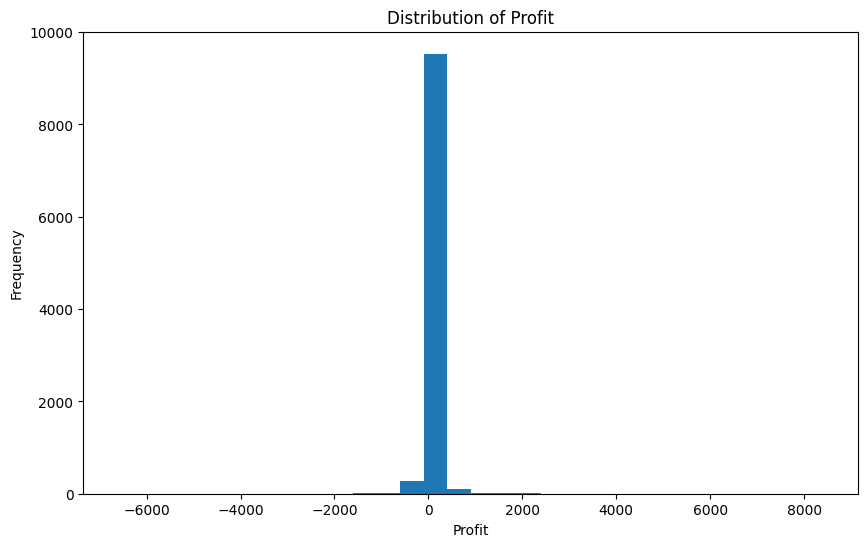

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Profit"],
    bins=30
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

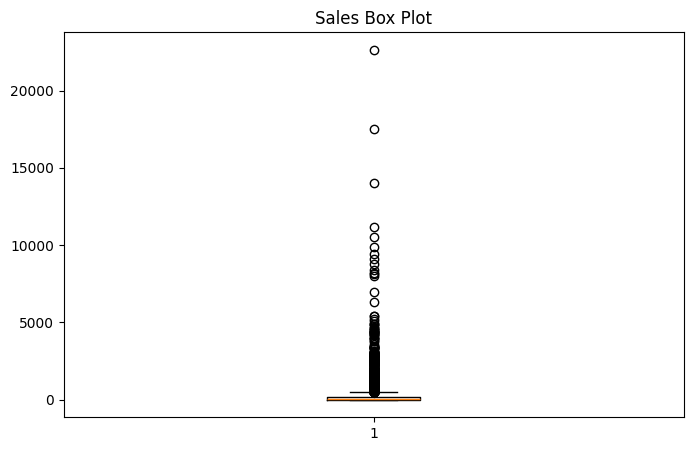

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"])

plt.title("Sales Box Plot")

plt.show()

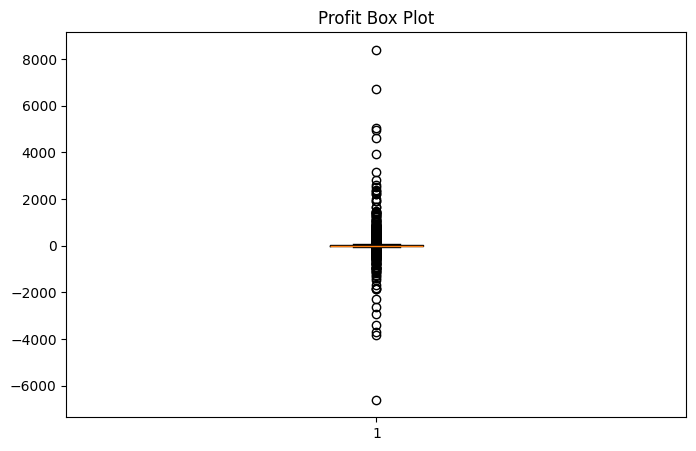

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Profit"])

plt.title("Profit Box Plot")

plt.show()

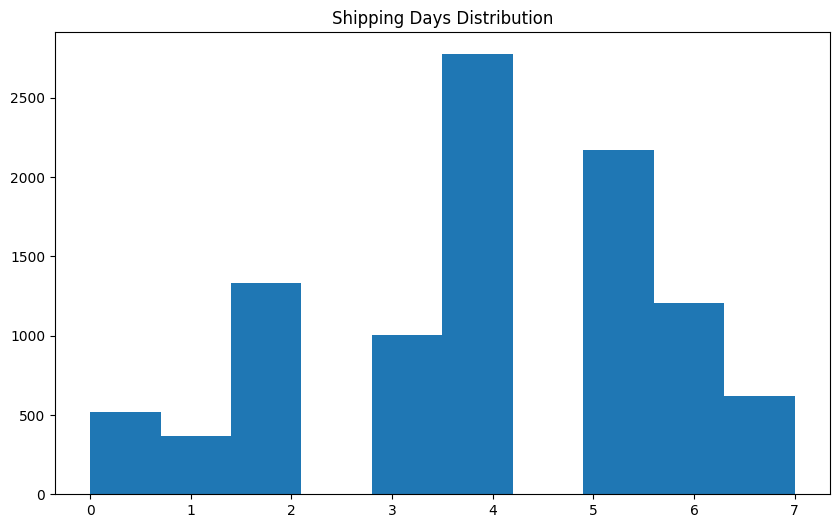

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Ship Days"],
    #bins=10
)

plt.title("Shipping Days Distribution")

plt.show()

EDA PHASE 2 ANALYSING ANOMALIES

In [ ]:
#Rank for finding diff in sales and profit

def find_rank_difference(column):
  sales_rank=(
      df.groupby(column)["Sales"]
      .sum()
      .rank(
          ascending=False,
          method="dense"
      )

  )

  print(sales_rank)
  profit_rank = (
      df.groupby(column)["Profit"]
      .sum()
      .rank(
          ascending=False,

          method="dense"
        )
    )

  result = pd.DataFrame({

        "Sales Rank":sales_rank,
        "Profit Rank":profit_rank

   })

  result["Rank Difference"] = abs(

        result["Sales Rank"] -
        result["Profit Rank"]

    )


  return result.sort_values(
        by="Rank Difference",
        ascending=False
    )

find_rank_difference("Ship Mode")

Ship Mode
First Class       3.0
Same Day          4.0
Second Class      2.0
Standard Class    1.0
Name: Sales, dtype: float64


,Sales Rank,Profit Rank,Rank Difference
Ship Mode,,,
First Class,3.0,3.0,0.0
Same Day,4.0,4.0,0.0
Second Class,2.0,2.0,0.0
Standard Class,1.0,1.0,0.0


In [ ]:
find_rank_difference("Sub-Category")

Sub-Category
Accessories     7.0
Appliances     10.0
Art            14.0
Binders         5.0
Bookcases       9.0
Chairs          2.0
Copiers         8.0
Envelopes      15.0
Fasteners      17.0
Furnishings    11.0
Labels         16.0
Machines        6.0
Paper          12.0
Phones          1.0
Storage         3.0
Supplies       13.0
Tables          4.0
Name: Sales, dtype: float64


,Sales Rank,Profit Rank,Rank Difference
Sub-Category,,,
Tables,4.0,17.0,13.0
Paper,12.0,4.0,8.0
Machines,6.0,13.0,7.0
Bookcases,9.0,16.0,7.0
Copiers,8.0,1.0,7.0
Envelopes,15.0,10.0,5.0
Accessories,7.0,3.0,4.0
Labels,16.0,12.0,4.0
Chairs,2.0,6.0,4.0


In [ ]:
find_rank_difference("Category")

Category
Furniture          2.0
Office Supplies    3.0
Technology         1.0
Name: Sales, dtype: float64


,Sales Rank,Profit Rank,Rank Difference
Category,,,
Furniture,2.0,3.0,1.0
Office Supplies,3.0,2.0,1.0
Technology,1.0,1.0,0.0


In [ ]:
cs=find_rank_difference("Customer Name")
cs.head(50)

Customer Name
Aaron Bergman         619.0
Aaron Hawkins         460.0
Aaron Smayling        271.0
Adam Bellavance        42.0
Adam Hart             238.0
                      ...  
Xylona Preis          366.0
Yana Sorensen          59.0
Yoseph Carroll         98.0
Zuschuss Carroll       38.0
Zuschuss Donatelli    502.0
Name: Sales, Length: 793, dtype: float64


,Sales Rank,Profit Rank,Rank Difference
Customer Name,,,
Sean Miller,1.0,604.0,603.0
Becky Martin,13.0,601.0,588.0
Grant Thornton,22.0,610.0,588.0
Natalie Fritzler,32.0,602.0,570.0
Sean Braxton,37.0,605.0,568.0
Peter Fuller,25.0,582.0,557.0
Zuschuss Carroll,38.0,595.0,557.0
Joseph Holt,39.0,583.0,544.0
Joseph Airdo,63.0,590.0,527.0


In [ ]:
city_rank=find_rank_difference("City")
city_rank.head(10)

City
Aberdeen       458.0
Abilene        478.0
Akron          132.0
Albuquerque    147.0
Alexandria      72.0
               ...  
Woonsocket     388.0
Yonkers         46.0
York           272.0
Yucaipa        444.0
Yuma           268.0
Name: Sales, Length: 531, dtype: float64


,Sales Rank,Profit Rank,Rank Difference
City,,,
Philadelphia,5.0,391.0,386.0
Houston,6.0,390.0,384.0
Chicago,7.0,387.0,380.0
Jacksonville,9.0,382.0,373.0
San Antonio,17.0,389.0,372.0
Burlington,18.0,386.0,368.0
Dallas,20.0,385.0,365.0
Aurora,31.0,383.0,352.0
Lancaster,36.0,388.0,352.0


In [ ]:
find_rank_difference("State")

State
Alabama                 27.0
Arizona                 16.0
Arkansas                31.0
California               1.0
Colorado                18.0
Connecticut             30.0
Delaware                22.0
District of Columbia    44.0
Florida                  6.0
Georgia                 13.0
Idaho                   42.0
Illinois                 7.0
Indiana                 12.0
Iowa                    41.0
Kansas                  43.0
Kentucky                14.0
Louisiana               34.0
Maine                   47.0
Maryland                23.0
Massachusetts           21.0
Michigan                 9.0
Minnesota               20.0
Mississippi             33.0
Missouri                25.0
Montana                 39.0
Nebraska                37.0
Nevada                  29.0
New Hampshire           38.0
New Jersey              15.0
New Mexico              40.0
New York                 2.0
North Carolina          11.0
North Dakota            49.0
Ohio                     8.0
Oklahoma

,Sales Rank,Profit Rank,Rank Difference
State,,,
Texas,3.0,49.0,46.0
Pennsylvania,5.0,47.0,42.0
Ohio,8.0,48.0,40.0
Illinois,7.0,46.0,39.0
Florida,6.0,41.0,35.0
North Carolina,11.0,45.0,34.0
Colorado,18.0,44.0,26.0
Arizona,16.0,42.0,26.0
Tennessee,19.0,43.0,24.0


In [ ]:
find_rank_difference("Region")

Region
Central    3.0
East       2.0
South      4.0
West       1.0
Name: Sales, dtype: float64


,Sales Rank,Profit Rank,Rank Difference
Region,,,
Central,3.0,4.0,1.0
South,4.0,3.0,1.0
East,2.0,2.0,0.0
West,1.0,1.0,0.0


In [ ]:
monthly_sales = (
    df.groupby([df["Order Date"].dt.to_period('M'),"Category"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

monthly_sales.head(10)

,Order Date,Category,Sales
0,2014-01,Furniture,6243.0
1,2014-01,Office Supplies,4852.0
2,2014-01,Technology,3143.0
3,2014-02,Furniture,1840.0
4,2014-02,Office Supplies,1070.0
5,2014-02,Technology,1608.0
6,2014-03,Furniture,14575.0
7,2014-03,Office Supplies,8603.0
8,2014-03,Technology,32510.0
9,2014-04,Furniture,7944.0


In [ ]:
monthly_profit = (
    df.groupby([df["Order Date"].dt.to_period('M'),"Category"])["Profit"]
      .sum()
      .reset_index()
)

monthly_profit["Order Date"] = monthly_sales["Order Date"].astype(str)

monthly_profit.head(10)

,Order Date,Category,Profit
0,2014-01,Furniture,804.0
1,2014-01,Office Supplies,785.0
2,2014-01,Technology,857.0
3,2014-02,Furniture,121.0
4,2014-02,Office Supplies,173.0
5,2014-02,Technology,565.0
6,2014-03,Furniture,-1131.0
7,2014-03,Office Supplies,1267.0
8,2014-03,Technology,359.0
9,2014-04,Furniture,555.0


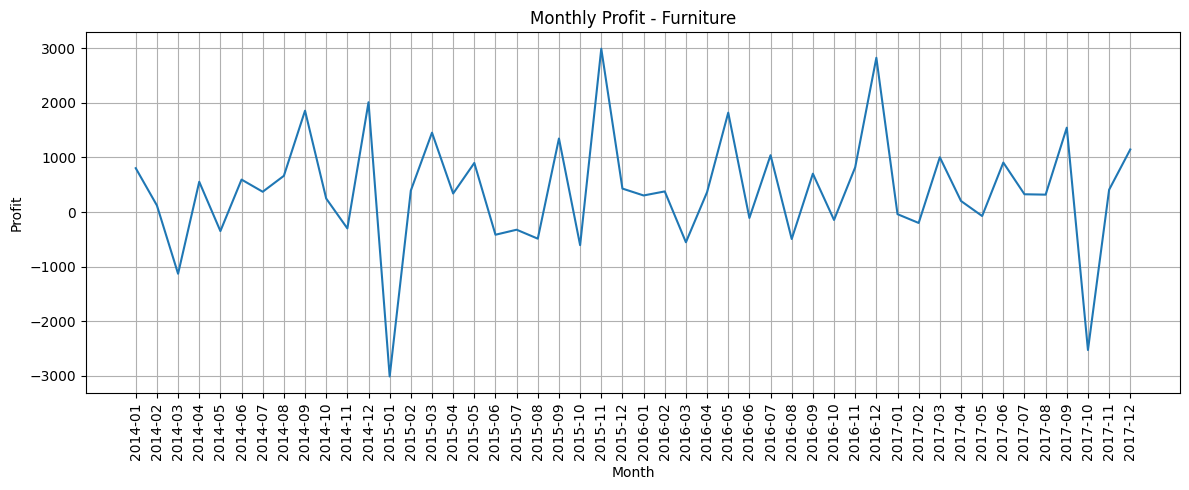

In [ ]:
categories = monthly_profit["Category"].unique()

# for category in categories:
temp = monthly_profit[monthly_profit["Category"] == "Furniture"]
# print(temp)
plt.figure(figsize=(12,5))
plt.plot(temp["Order Date"], temp["Profit"])
plt.title(f"Monthly Profit - {"Furniture"}")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
query="""
select "Customer Name","Product Name", Category, Sales, Discount, Profit,"Order Date"
from Superstore
where "Order Date" >= '2015-01-01' and "Order Date" <= '2015-10-30' and Category = 'Furniture'
order by "Profit";
"""
pd.read_sql(query, conn)

,Customer Name,Product Name,Category,Sales,Discount,Profit,Order Date
0,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4298.0,40,-1862.0,2015-01-28 00:00:00
1,Tracy Blumstein,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,3083.0,50,-1665.0,2015-09-17 00:00:00
2,Michael Grace,Hon Rectangular Conference Tables,Furniture,796.0,50,-526.0,2015-06-22 00:00:00
3,Amy Hunt,O'Sullivan Living Dimensions 5-Shelf Bookcases,Furniture,1352.0,32,-438.0,2015-01-03 00:00:00
4,Sean O'Donnell,Bretford CR4500 Series Slim Rectangular Table,Furniture,958.0,45,-383.0,2015-10-11 00:00:00
...,...,...,...,...,...,...,...
303,Deanra Eno,Hon Olson Stacker Stools,Furniture,1408.0,0,394.0,2015-09-24 00:00:00
304,Zuschuss Carroll,Hon Multipurpose Stacking Arm Chairs,Furniture,1516.0,0,394.0,2015-09-13 00:00:00
305,Giulietta Baptist,Global Comet Stacking Arm Chair,Furniture,1690.0,0,423.0,2015-09-21 00:00:00
306,Ellis Ballard,Bush Advantage Collection Racetrack Conference...,Furniture,3394.0,0,611.0,2015-03-26 00:00:00


In [ ]:
query="""
select "Customer Name","Product Name", Category, Sales, Discount, Profit,"Order Date"
from Superstore
where "Order Date" >= '2017-01-01' and "Order Date" <= '2017-10-30' and Category = 'Furniture'
order by "Profit";
"""
pd.read_sql(query, conn)

,Customer Name,Product Name,Category,Sales,Discount,Profit,Order Date
0,Dean percer,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,2314.0,40,-1003.0,2017-10-02 00:00:00
1,Victoria Pisteka,Balt Solid Wood Round Tables,Furniture,1875.0,40,-969.0,2017-10-16 00:00:00
2,Tom Prescott,HON 5400 Series Task Chairs for Big and Tall,Furniture,4416.0,30,-631.0,2017-08-17 00:00:00
3,Michelle Moray,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,766.0,50,-567.0,2017-09-08 00:00:00
4,Caroline Jumper,Bush Advantage Collection Racetrack Conference...,Furniture,933.0,45,-458.0,2017-05-01 00:00:00
...,...,...,...,...,...,...,...
467,Rick Wilson,Hon 4070 Series Pagoda Armless Upholstered Sta...,Furniture,1459.0,0,423.0,2017-05-07 00:00:00
468,Justin Deggeller,"Lifetime Advantage Folding Chairs, 4/Carton",Furniture,1527.0,0,427.0,2017-03-25 00:00:00
469,Clay Ludtke,"Global Leather and Oak Executive Chair, Black",Furniture,1806.0,0,524.0,2017-03-21 00:00:00
470,Helen Wasserman,Hon 4070 Series Pagoda Round Back Stacking Chairs,Furniture,1926.0,0,539.0,2017-06-01 00:00:00


In [ ]:
query="""
select "Customer Name","Product Name", Category, "Sub-Category" , Sales, Discount, Profit,"Order Date"
from Superstore
where "Product Name" like	"%Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish%"
"""
pd.read_sql(query, conn)

,Customer Name,Product Name,Category,Sub-Category,Sales,Discount,Profit,Order Date
0,Tracy Blumstein,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,3083.0,50,-1665.0,2015-09-17 00:00:00
1,Anna Gayman,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,2396.0,32,-317.0,2016-09-08 00:00:00
2,Peter Fuller,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,4229.0,20,159.0,2015-09-17 00:00:00
3,Maureen Gastineau,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,1498.0,15,141.0,2017-06-08 00:00:00
4,Quincy Jones,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,4405.0,0,1013.0,2015-11-08 00:00:00


In [ ]:
df.groupby("Category")["Discount"].mean()

,Discount
Category,
Furniture,17.392268
Office Supplies,15.728510
Technology,13.232269


In [ ]:
category_summary = (
    df.groupby("Category").agg({"Sales":"sum","Profit":"sum"})
)

category_summary["Profit margin"] = (category_summary["Profit"]/ category_summary["Sales"] * 100)
category_summary

,Sales,Profit,Profit margin
Category,,,
Furniture,742003.0,18444.0,2.485704
Office Supplies,719118.0,122473.0,17.031002
Technology,836219.0,145423.0,17.390540


In [ ]:
category_summary=(
df.groupby("Sub-Category").agg({"Sales":"sum","Profit":"sum"})
)

category_summary

,Sales,Profit
Sub-Category,,
Accessories,167400.0,41928.0
Appliances,107537.0,18132.0
Art,27136.0,6529.0
Binders,203425.0,30200.0
Bookcases,114879.0,-3479.0
Chairs,328453.0,26586.0
Copiers,149530.0,55618.0
Envelopes,16477.0,6956.0
Fasteners,3024.0,952.0


In [ ]:
df.groupby("Sub-Category")["Discount"].mean()

,Discount
Sub-Category,
Accessories,7.845161
Appliances,16.652361
Art,7.487437
Binders,37.229153
Bookcases,21.114035
Chairs,17.017828
Copiers,16.176471
Envelopes,8.031496
Fasteners,8.202765


In [ ]:
furniture = df[df["Category"] == "Furniture"]

sales = furniture["Sales"].sum()
profit = furniture["Profit"].sum()

profit_margin = profit / sales * 100

print(profit_margin)



2.48570423569716


In [ ]:
furniture.groupby("Discount")["Profit"].mean()

,Profit
Discount,
0,69.534689
10,93.539474
15,27.230769
20,10.177236
30,-48.144144
32,-88.518519
40,-215.800000
45,-226.636364
50,-238.388889


HIGH DISCOUNT IS A MAJOR PROBLEM FOR FURNITURE WHICH I LEADING TO A BIGGER LOSS

In [ ]:
furniture.groupby("Sub-Category")[["Sales","Profit"]].sum()

,Sales,Profit
Sub-Category,,
Bookcases,114879.0,-3479.0
Chairs,328453.0,26586.0
Furnishings,91704.0,13070.0
Tables,206967.0,-17733.0


In [ ]:
sub = furniture.groupby("Sub-Category")[["Sales","Profit"]].sum()

sub["Margin %"] = (
    sub["Profit"] /
    sub["Sales"] * 100
)

sub.sort_values("Margin %")

,Sales,Profit,Margin %
Sub-Category,,,
Tables,206967.0,-17733.0,-8.568033
Bookcases,114879.0,-3479.0,-3.028404
Chairs,328453.0,26586.0,8.094309
Furnishings,91704.0,13070.0,14.252377


In [ ]:
furniture.groupby("Sub-Category")["Discount"].mean()

,Discount
Sub-Category,
Bookcases,21.114035
Chairs,17.017828
Furnishings,13.834901
Tables,26.128527


In [ ]:
df[(df["Category"]=="Furniture") & (df["Sub-Category"]=="Tables")].groupby("State")[["Sales","Profit"]].sum().sort_values(
    by="Profit"
)

,Sales,Profit
State,,
New York,13780.0,-4535.0
Illinois,6549.0,-4311.0
North Carolina,9683.0,-3684.0
Ohio,7888.0,-2715.0
Tennessee,6215.0,-2663.0
Pennsylvania,8052.0,-2588.0
Florida,5485.0,-2493.0
Arizona,3996.0,-2281.0
Texas,15758.0,-2215.0


In [ ]:
states_by_region = (
    df.groupby("Region")["State"]
    .unique()
)

print(states_by_region.head(50))

Region
Central    [Texas, Wisconsin, Nebraska, Illinois, Minneso...
East       [Pennsylvania, Delaware, New York, Ohio, Conne...
South      [Kentucky, Florida, North Carolina, Virginia, ...
West       [California, Washington, Utah, Arizona, Oregon...
Name: State, dtype: object


In [ ]:
tables = df[(df["Category"]=="Furniture")&(df["Sub-Category"]=="Tables")]
tables.groupby("Product Name")[["Profit","Sales"]].sum().sort_values(by="Profit").head(10)

,Profit,Sales
Product Name,,
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.0,9918.0
Bush Advantage Collection Racetrack Conference Table,-1933.0,9546.0
Balt Solid Wood Round Tables,-1202.0,6519.0
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,-1149.0,1707.0
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",-1148.0,4446.0
Bretford ï¿½Just In Timeï¿½ Height-Adjustable Multi-Task Work Tables,-964.0,5636.0
"Bevis Oval Conference Table, Walnut",-856.0,6941.0
BPI Conference Tables,-796.0,2241.0
Hon 94000 Series Round Tables,-681.0,7406.0


In [ ]:
tables.groupby("Product Name")["Discount"].describe()

,count,mean,std,min,25%,50%,75%,max
Product Name,,,,,,,,
Anderson Hickey Conga Table Tops & Accessories,2.0,30.000000,14.142136,20.0,25.0,30.0,35.00,40.0
BPI Conference Tables,5.0,37.000000,21.095023,0.0,40.0,45.0,50.00,50.0
Balt Solid Wood Rectangular Table,4.0,26.250000,20.564938,0.0,15.0,30.0,41.25,45.0
Balt Solid Wood Round Tables,4.0,20.000000,23.094011,0.0,0.0,20.0,40.00,40.0
Balt Split Level Computer Training Table,5.0,38.000000,13.038405,20.0,30.0,40.0,50.00,50.0
"Barricks 18"" x 48"" Non-Folding Utility Table with Bottom Storage Shelf",5.0,32.000000,8.366600,20.0,30.0,30.0,40.00,40.0
"Barricks Non-Folding Utility Table with Steel Legs, Laminate Tops",1.0,20.000000,NaN,20.0,20.0,20.0,20.00,20.0
Bevis 36 x 72 Conference Tables,8.0,16.250000,15.059406,0.0,0.0,20.0,22.50,40.0
Bevis 44 x 96 Conference Tables,5.0,18.000000,24.899799,0.0,0.0,0.0,40.00,50.0


In [ ]:
tables = df[(df["Category"]== "Furniture") & (df["Sub-Category"]=="Tables")]
tables["Discount"].describe()

,Discount
count,319.000000
mean,26.128527
std,16.962197
min,0.000000
25%,20.000000
50%,30.000000
75%,40.000000
max,50.000000


In [ ]:
tables.groupby("Discount")[
    ["Sales","Profit"]
].sum()

,Sales,Profit
Discount,,
0,71583.0,13273.0
20,45429.0,-309.0
30,25179.0,-3402.0
40,45618.0,-16185.0
45,5485.0,-2493.0
50,13673.0,-8617.0


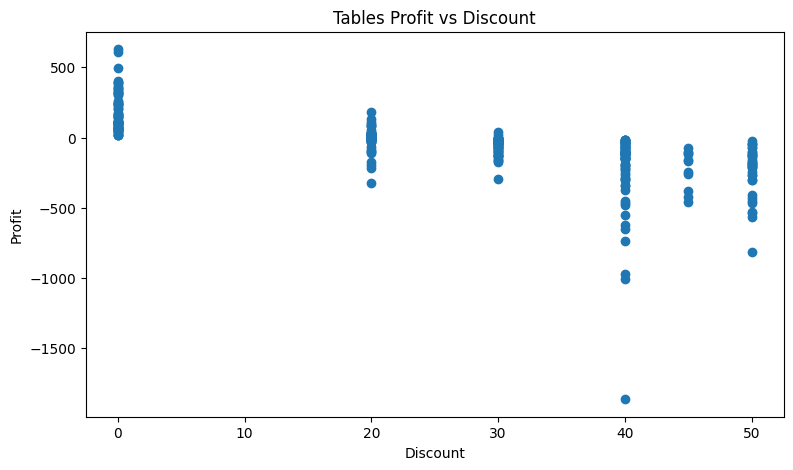

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.scatter(
    tables["Discount"],
    tables["Profit"]
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Tables Profit vs Discount")

plt.show()




In [ ]:
tables.groupby(["Discount","Product Name"]) [["Sales","Profit"]].sum().sort_values(by="Profit").head(20)

Sales  Profit
Discount Product Name                                                      
40       Chromcraft Bull-Nose Wood Oval Conference Table...  6943.0 -3008.0
         Balt Solid Wood Round Tables                        2947.0 -1523.0
         Riverside Furniture Oval Coffee Table, Oval End...  3958.0 -1188.0
         Bush Advantage Collection Racetrack Conference ...  3055.0 -1119.0
50       Bush Advantage Collection Racetrack Conference ...  1273.0  -814.0
40       Hon 94000 Series Round Tables                       1422.0  -735.0
50       BoxOffice By Design Rectangular and Half-Moon M...   985.0  -729.0
40       Bevis Oval Conference Table, Walnut                 1879.0  -720.0
50       Chromcraft 48" x 96" Racetrack Double Pedestal ...  1283.0  -718.0
40       Chromcraft Bull-Nose Wood 48" x 96" Rectangular...  1984.0  -694.0
         Hon Racetrack Conference Tables                     2048.0  -649.0
30       Office Impressions End Table, 20-1/2"H x 24"W x...  2764.0  -554.0
20       Bretford ï¿½Just In Timeï¿½ Height-Adjustable M...  3340.0  -543.0
40       Bevis Round Bullnose 29" High Table Top             2026.0  -540.0
50       Bretford ï¿½Just In Timeï¿½ Height-Adjustable M...   626.0  -538.0
         Hon Rectangular Conference Tables                    796.0  -526.0
         Hon 5100 Series Wood Tables                          727.0  -466.0
45       Bretford CR4500 Series Slim Rectangular Table       1150.0  -460.0
         Bush Advantage Collection Racetrack Conference ...   933.0  -458.0
40       Bretford Rectangular Conference Table Tops          1580.0  -448.0

In [ ]:
tables.groupby(
    "Discount"
)["Quantity"].sum()

,Quantity
Discount,
0,310
20,281
30,180
40,292
45,45
50,133


In [ ]:
tables.groupby(
    "Order ID"
)[["Sales","Profit"]].sum().sort_values(
    by="Profit"
).head(50)

,Sales,Profit
Order ID,,
CA-2015-116638,4298.0,-1862.0
US-2014-148838,3266.0,-1125.0
US-2017-162558,2314.0,-1003.0
CA-2017-159100,1875.0,-969.0
CA-2016-109869,1273.0,-814.0
CA-2014-108609,1422.0,-735.0
CA-2017-142090,1782.0,-653.0
US-2017-110576,2065.0,-620.0
US-2017-124968,766.0,-567.0


In [ ]:
tables.groupby(
    "Segment"
)[["Sales","Profit"]].sum()

,Sales,Profit
Segment,,
Consumer,99939.0,-9729.0
Corporate,70868.0,-4913.0
Home Office,36160.0,-3091.0


In [ ]:
tables[
    tables["Product Name"] ==
    "Chromcraft Bull-Nose Wood Oval Conference Tables & Bases"
][[
    "Order ID",
    "Sales",
    "Profit",
    "Discount",
    "Quantity",
    "Segment"
]].sort_values(by="Profit")

,Order ID,Sales,Profit,Discount,Quantity,Segment
9639,CA-2015-116638,4298.0,-1862.0,40,13,Consumer
5320,US-2017-162558,2314.0,-1003.0,40,7,Home Office
9899,US-2014-117380,331.0,-143.0,40,1,Home Office
2477,CA-2017-102750,1322.0,-99.0,20,3,Corporate
721,CA-2016-142335,1653.0,231.0,0,3,Corporate


In [ ]:
tables[
    tables["Product Name"] ==
    "Bush Advantage Collection Racetrack Conference Table"
][[
    "Order ID",
    "Sales",
    "Profit",
    "Discount",
    "Quantity",
    "Segment"
]].sort_values(by="Profit")

,Order ID,Sales,Profit,Discount,Quantity,Segment
463,CA-2016-109869,1273.0,-814.0,50,6,Home Office
5066,CA-2017-142090,1782.0,-653.0,40,7,Consumer
8235,CA-2017-102204,933.0,-458.0,45,4,Consumer
1669,US-2015-157154,1018.0,-373.0,40,4,Consumer
7305,CA-2014-137274,891.0,-153.0,30,3,Consumer
1948,CA-2017-157987,255.0,-93.0,40,1,Corporate
9857,CA-2015-164301,3394.0,611.0,0,8,Corporate


In [ ]:
tables[
    tables["Product Name"] ==
    "Balt Solid Wood Round Tables"
][[
    "Order ID",
    "Sales",
    "Profit",
    "Discount",
    "Quantity",
    "Segment"
]].sort_values(by="Profit")

,Order ID,Sales,Profit,Discount,Quantity,Segment
8993,CA-2017-159100,1875.0,-969.0,40,7,Corporate
2358,US-2014-148838,1072.0,-554.0,40,4,Corporate
2289,CA-2017-115154,893.0,80.0,0,2,Corporate
8468,US-2016-164196,2679.0,241.0,0,6,Corporate


In [ ]:
tables[
    tables["Product Name"] ==
    "BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables"
][[
    "Order ID",
    "Sales",
    "Profit",
    "Discount",
    "Quantity",
    "Segment"
]].sort_values(by="Profit")

,Order ID,Sales,Profit,Discount,Quantity,Segment
1713,US-2017-124968,766.0,-567.0,50,7,Consumer
7344,CA-2017-168389,722.0,-420.0,45,6,Corporate
201,CA-2014-133690,219.0,-162.0,50,2,Consumer


In [ ]:
tables[
    tables["Product Name"] ==
    "Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer"
][[
    "Order ID",
    "Sales",
    "Profit",
    "Discount",
    "Quantity",
    "Segment"
]].sort_values(by="Profit")

,Order ID,Sales,Profit,Discount,Quantity,Segment
949,US-2017-110576,2065.0,-620.0,40,12,Home Office
7649,CA-2015-101889,1549.0,-465.0,40,9,Corporate
3015,US-2015-138919,344.0,-103.0,40,2,Home Office
5262,CA-2014-105165,201.0,-23.0,30,1,Home Office
8418,CA-2017-118199,287.0,63.0,0,1,Home Office


the more quantity and discount the more loss we are bearing -
0qty has profit even if sell more quantity and  more discount even if less quantity is profit

0qty shud be given for 30 disc or more


1 INSIGHT IS DONE OF EDA PHASE 2

In [ ]:
#2 INSIGHTS OF EDA PHASE 2 central too less profit margin
df.groupby("Region")[["Sales","Profit"]].sum().sort_values(by="Profit")

,Sales,Profit
Region,,
Central,501253.0,39718.0
South,391748.0,46721.0
East,678828.0,91518.0
West,725511.0,108383.0


In [ ]:
region = df.groupby("Region")[["Sales","Profit"]].sum()

region["Profit Margin %"] = (
    region["Profit"]/region["Sales"]
)*100

region.round(2)

,Sales,Profit,Profit Margin %
Region,,,
Central,501253.0,39718.0,7.92
East,678828.0,91518.0,13.48
South,391748.0,46721.0,11.93
West,725511.0,108383.0,14.94


In [ ]:
df[df["Region"]=="Central"].groupby("Category")[["Sales","Profit"]].sum().round(2)

,Sales,Profit
Category,,
Furniture,163789.0,-2867.0
Office Supplies,167032.0,8895.0
Technology,170432.0,33690.0


In [ ]:
df[df["Region"]=="Central"].groupby("Sub-Category")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Sub-Category,,
Furnishings,15256.0,-3902.0
Tables,39152.0,-3561.0
Appliances,23581.0,-2642.0
Bookcases,24153.0,-1998.0
Machines,26800.0,-1485.0
Binders,56926.0,-1053.0
Supplies,9470.0,-659.0
Fasteners,776.0,237.0
Labels,2454.0,1076.0


In [ ]:
sub = furniture.groupby("Sub-Category")[["Sales","Profit"]].sum()

sub["Margin %"] = (
    sub["Profit"] /
    sub["Sales"] * 100
)

sub.sort_values("Margin %")

,Sales,Profit,Margin %
Sub-Category,,,
Tables,206967.0,-17733.0,-8.568033
Bookcases,114879.0,-3479.0,-3.028404
Chairs,328453.0,26586.0,8.094309
Furnishings,91704.0,13070.0,14.252377


In [ ]:


central = df[df["Region"]== "Central"]

central.groupby("Discount")[["Sales","Profit"]].sum().sort_values(by="Profit")

,Sales,Profit
Discount,,
80,16963.0,-30546.0
30,64924.0,-6535.0
60,6649.0,-5944.0
50,6549.0,-4311.0
40,19548.0,-2666.0
32,14491.0,-2390.0
10,7735.0,1916.0
20,121225.0,14070.0
0,243169.0,76124.0


In [ ]:
df[df["Region"]=="Central"]\
.groupby("Segment")[["Sales","Profit"]]\
.sum().round(2)

,Sales,Profit
Segment,,
Consumer,252039.0,8571.0
Corporate,157998.0,18709.0
Home Office,91216.0,12438.0


Consumer is underperforming in central

In [ ]:
df[df["Region"]=="South"]\
.groupby("Segment")[["Sales","Profit"]]\
.sum().round(2)

,Sales,Profit
Segment,,
Consumer,195601.0,26910.0
Corporate,121892.0,15207.0
Home Office,74255.0,4604.0


In [ ]:
df[df["Region"]=="West"]\
.groupby("Segment")[["Sales","Profit"]]\
.sum().round(2)

,Sales,Profit
Segment,,
Consumer,362905.0,57426.0
Corporate,225870.0,34432.0
Home Office,136736.0,16525.0


In [ ]:
df[df["Region"]=="East"]\
.groupby("Segment")[["Sales","Profit"]]\
.sum().round(2)

,Sales,Profit
Segment,,
Consumer,350944.0,41201.0
Corporate,200420.0,23616.0
Home Office,127464.0,26701.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Furnishings"
].groupby("Product Name")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Product Name,,
"Tenex Chairmat w/ Average Lip, 45"" x 53""",545.0,-681.0
Tenex Antistatic Computer Chair Mats,342.0,-427.0
"Deflect-o RollaMat Studded, Beveled Mat for Medium Pile Carpeting",406.0,-426.0
Luxo Professional Fluorescent Magnifier Lamp with Clamp-Mount Base,420.0,-357.0
Eldon ClusterMat Chair Mat with Cordless Antistatic Protection,801.0,-252.0
...,...,...
"Advantus Employee of the Month Certificate Frame, 11 x 13-1/2",186.0,76.0
Luxo Professional Combination Clamp-On Lamps,307.0,80.0
Deflect-o Glass Clear Studded Chair Mats,373.0,82.0


In [ ]:
central[
    central["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
60,6649.0,-5944.0
0,8607.0,2042.0


In [ ]:
central[
    central["Sub-Category"]=="Furnishings"
][["Product Name",
   "Discount",
   "Quantity",
   "Sales",
   "Profit"]].sort_values(by="Profit")

,Product Name,Discount,Quantity,Sales,Profit
3316,Tenex Antistatic Computer Chair Mats,60,5,342.0,-427.0
9592,"Tenex Chairmat w/ Average Lip, 45"" x 53""",60,5,303.0,-378.0
238,Luxo Professional Fluorescent Magnifier Lamp w...,60,5,420.0,-357.0
4229,"Deflect-o RollaMat Studded, Beveled Mat for Me...",60,9,332.0,-349.0
467,Eldon ClusterMat Chair Mat with Cordless Antis...,60,7,255.0,-312.0
...,...,...,...,...,...
5371,Luxo Professional Combination Clamp-On Lamps,0,3,307.0,80.0
3998,Deflect-o Glass Clear Studded Chair Mats,0,6,373.0,82.0
9447,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",0,5,477.0,138.0
2648,"3M Polarizing Task Lamp with Clamp Arm, Light ...",0,6,822.0,214.0


In [ ]:
west = df[df["Region"]=="West"]
west[
    west["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20,4936.0,502.0
0,25135.0,7144.0


In [ ]:
east = df[df["Region"]=="East"]
east[
    east["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20,11433.0,803.0
0,17634.0,5081.0


In [ ]:
central[central["Discount"] >= 50][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
9774,GBC DocuBind P400 Electric Binding System,Binders,80,2178.0,-3702.0,8
4991,Ibico EPK-21 Electric Binding System,Binders,80,1890.0,-2929.0,5
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Binders,80,1525.0,-2288.0,6
1199,GBC DocuBind P400 Electric Binding System,Binders,80,1089.0,-1851.0,4
3324,GBC DocuBind TL300 Electric Binding System,Binders,80,897.0,-1480.0,5
...,...,...,...,...,...,...
2106,Acco 3-Hole Punch,Binders,80,1.0,-1.0,1
1358,"DAX Value U-Channel Document Frames, Easel Back",Furnishings,60,2.0,-1.0,1
1418,Longer-Life Soft White Bulbs,Furnishings,60,5.0,-1.0,4
9292,Acco Suede Grain Vinyl Round Ring Binder,Binders,80,1.0,-1.0,1


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Appliances"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
80,3381.0,-8634.0
10,4324.0,1084.0
0,15876.0,4908.0


In [ ]:
central = df[df["Region"]=="South"]

central[
    central["Sub-Category"]=="Appliances"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20,9611.0,1039.0
0,9914.0,3084.0


In [ ]:
central = df[df["Region"]=="East"]

central[
    central["Sub-Category"]=="Appliances"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20,9471.0,1181.0
0,24720.0,7209.0


In [ ]:
central = df[df["Region"]=="West"]

central[
    central["Sub-Category"]=="Appliances"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20,2678.0,279.0
0,27562.0,7982.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
80,13582.0,-21912.0
0,43344.0,20859.0


In [ ]:
central = df[df["Region"]=="East"]

central[
    central["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,8186.0,-5977.0
0,12857.0,6140.0
20,32457.0,11096.0


In [ ]:
central = df[df["Region"]=="South"]

central[
    central["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,11400.0,-8411.0
0,25632.0,12307.0


In [ ]:
central = df[df["Region"]=="West"]

central[
    central["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,2976.0,-2225.0
20,52991.0,18323.0


In [ ]:
central = df[df["Region"]=="West"]

central[
    central["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50,7124.0,-4306.0
20,45429.0,-309.0
0,32202.0,6092.0


In [ ]:
central = df[df["Region"]=="East"]

central[
    central["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
40,29720.0,-9838.0
30,9421.0,-1187.0


In [ ]:
central = df[df["Region"]=="South"]

central[
    central["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
40,15898.0,-6347.0
45,5485.0,-2493.0
0,22536.0,4216.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50,6549.0,-4311.0
30,15758.0,-2215.0
0,16845.0,2965.0


In [ ]:
central = df[df["Region"]=="West"]

central[
    central["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,2460.0,-3898.0
0,5987.0,831.0
15,27560.0,1416.0


In [ ]:
central = df[df["Region"]=="South"]

central[
    central["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20,4064.0,-221.0
0,6836.0,1560.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
32,14491.0,-2390.0
30,4281.0,-555.0
0,5381.0,947.0


In [ ]:
central = df[df["Region"]=="East"]

central[
    central["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50,7305.0,-4256.0
20,22779.0,352.0
0,13735.0,2735.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
40,19548.0,-2666.0
0,84.0,23.0
30,3757.0,326.0
10,3411.0,832.0


In [ ]:
central = df[df["Region"]=="South"]

central[
    central["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50,37934.0,-7635.0
0,15956.0,6196.0


In [ ]:
central = df[df["Region"]=="West"]

central[
    central["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,4490.0,-5589.0
20,37955.0,4971.0


In [ ]:
central = df[df["Region"]=="East"]

central[
    central["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,11112.0,-13989.0
0,54995.0,20918.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
32,14491.0,-2390.0
30,4281.0,-555.0
0,5381.0,947.0


In [ ]:
central = df[df["Region"]=="Central"]

central[
    central["Sub-Category"]=="Appliances"
].groupby("Product Name")[["Discount","Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Discount,Sales,Profit
Product Name,,,
3.6 Cubic Foot Counter Height Office Refrigerator,240,531.0,-1379.0
Hoover Upright Vacuum With Dirt Cup,80,1332.0,-929.0
Avanti 4.4 Cu. Ft. Refrigerator,80,181.0,-471.0
Kensington 7 Outlet MasterPiece Power Center,80,178.0,-454.0
Euro Pro Shark Stick Mini Vacuum,160,122.0,-330.0
...,...,...,...
Sanyo 2.5 Cubic Foot Mid-Size Office Refrigerators,0,839.0,218.0
Honeywell Quietcare HEPA Air Cleaner,10,755.0,228.0
Hoover WindTunnel Plus Canister Vacuum,0,1090.0,305.0


In [ ]:
east = df[df["Region"]=="East"]
east[
    east["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,11112.0,-13989.0
0,54995.0,20918.0


In [ ]:
east = df[df["Region"]=="South"]
east[
    east["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50,37934.0,-7635.0
0,15956.0,6196.0


In [ ]:
east = df[df["Region"]=="West"]
east[
    east["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70,4490.0,-5589.0
20,37955.0,4971.0


In [ ]:
east = df[df["Region"]=="Central"]
east[
    east["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
40,19548.0,-2666.0
0,84.0,23.0
30,3757.0,326.0
10,3411.0,832.0


In [ ]:
states = ["Florida","North Carolina","Illinois",
          "Pennsylvania","Ohio","Texas"]

df[df["State"].isin(states)].groupby("State")[["Sales","Profit"]].sum().round(2).sort_values(by="Profit")


,Sales,Profit
State,,
Texas,170187.0,-25715.0
Ohio,78253.0,-16963.0
Pennsylvania,116522.0,-15550.0
Illinois,80162.0,-12607.0
North Carolina,55604.0,-7495.0
Florida,89479.0,-3412.0


In [ ]:
state = df[df["State"].isin(states)]\
.groupby("State")[["Sales","Profit"]].sum()

state["Profit Margin %"] = (state["Profit"]/state["Sales"])*100

state.round(2)

,Sales,Profit,Profit Margin %
State,,,
Florida,89479.0,-3412.0,-3.81
Illinois,80162.0,-12607.0,-15.73
North Carolina,55604.0,-7495.0,-13.48
Ohio,78253.0,-16963.0,-21.68
Pennsylvania,116522.0,-15550.0,-13.35
Texas,170187.0,-25715.0,-15.11


In [ ]:
texas = df[df["State"]=="Texas"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Office Supplies,44488.0,-18575.0
Furniture,60586.0,-10430.0
Technology,65113.0,3290.0


In [ ]:
texas = df[df["State"]=="Ohio"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,35675.0,-12650.0
Furniture,24196.0,-4205.0
Office Supplies,18382.0,-108.0


In [ ]:
texas = df[df["State"]=="Pennsylvania"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,39347.0,-7191.0
Office Supplies,34954.0,-5171.0
Technology,42221.0,-3188.0


In [ ]:
texas = df[df["State"]=="Illinois"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,28270.0,-9076.0
Office Supplies,19908.0,-8353.0
Technology,31984.0,4822.0


In [ ]:
texas = df[df["State"]=="North Carolina"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,26084.0,-3583.0
Furniture,15156.0,-3486.0
Office Supplies,14364.0,-426.0


In [ ]:
texas = df[df["State"]=="Florida"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,22988.0,-2259.0
Office Supplies,19523.0,-1681.0
Technology,46968.0,528.0


In [ ]:
texas = df[df["State"]=="Texas"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Office Supplies,44488.0,-18575.0
Furniture,60586.0,-10430.0
Technology,65113.0,3290.0


In [ ]:
texas = df[df["State"]=="Mississippi"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,4317.0,944.0
Technology,2823.0,986.0
Office Supplies,3632.0,1242.0


In [ ]:
texas = df[df["State"]=="Nevada"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,5137.0,512.0
Furniture,4635.0,524.0
Office Supplies,6957.0,2280.0


In [ ]:
state = (
    df[df["State"].isin(["Nevada", "Mississippi"])]
    .groupby("State")[["Sales", "Profit"]]
    .sum()
)

state["Profit Margin %"] = (
    state["Profit"] / state["Sales"]
) * 100

state.round(2)

,Sales,Profit,Profit Margin %
State,,,
Mississippi,10772.0,3172.0,29.45
Nevada,16729.0,3316.0,19.82


In [ ]:
Mississippi = df[df["State"]=="Nevada"]

Mississippi.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,5137.0,512.0
Furniture,4635.0,524.0
Office Supplies,6957.0,2280.0


In [ ]:
texas = df[df["State"]=="Texas"]

texas.groupby("Sub-Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Sub-Category,,
Binders,9042.0,-14705.0
Appliances,2408.0,-6150.0
Furnishings,3769.0,-3312.0
Machines,19548.0,-2666.0
Chairs,26568.0,-2513.0
Bookcases,14491.0,-2390.0
Tables,15758.0,-2215.0
Supplies,4518.0,-836.0
Storage,15727.0,-761.0


In [ ]:
df[
    (df["State"] == "Texas") &(df["Category"] == "Office Supplies")].groupby("Sub-Category")[["Sales", "Profit"]] \
 .sum() \
 .sort_values(by="Profit", ascending=False) \
 .round(2)

,Sales,Profit
Sub-Category,,
Paper,6982.0,2427.0
Envelopes,2532.0,846.0
Art,2365.0,321.0
Labels,585.0,202.0
Fasteners,329.0,81.0
Storage,15727.0,-761.0
Supplies,4518.0,-836.0
Appliances,2408.0,-6150.0
Binders,9042.0,-14705.0


In [ ]:
office_supplies = (
    df[
        (df["State"] == "Texas") &
        (df["Category"] == "Office Supplies")
    ]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

office_supplies["Profit Margin %"] = (
    office_supplies["Profit"] / office_supplies["Sales"]
) * 100

office_supplies.sort_values(
    by="Profit Margin %",
    ascending=False
).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Paper,6982.0,2427.0,34.76
Labels,585.0,202.0,34.53
Envelopes,2532.0,846.0,33.41
Fasteners,329.0,81.0,24.62
Art,2365.0,321.0,13.57
Storage,15727.0,-761.0,-4.84
Supplies,4518.0,-836.0,-18.50
Binders,9042.0,-14705.0,-162.63
Appliances,2408.0,-6150.0,-255.40


In [ ]:
office_supplies = (
    df[
        (df["State"] == "California") &
        (df["Category"] == "Office Supplies")
    ]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

office_supplies["Profit Margin %"] = (
    office_supplies["Profit"] / office_supplies["Sales"]
) * 100

office_supplies.sort_values(
    by="Profit Margin %",
    ascending=False
).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Paper,16762.0,7978.0,47.60
Envelopes,3238.0,1528.0,47.19
Labels,2905.0,1370.0,47.16
Fasteners,480.0,200.0,41.67
Binders,28478.0,10006.0,35.14
Art,5503.0,1615.0,29.35
Appliances,24178.0,6993.0,28.92
Storage,45116.0,7200.0,15.96
Supplies,15721.0,862.0,5.48


In [ ]:
office_supplies = (
    df[
        (df["State"] == "Arkansas") &
        (df["Category"] == "Office Supplies")
    ]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

office_supplies["Profit Margin %"] = (
    office_supplies["Profit"] / office_supplies["Sales"]
) * 100

office_supplies.sort_values(
    by="Profit Margin %",
    ascending=False
).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Envelopes,311.0,149.0,47.91
Paper,805.0,383.0,47.58
Binders,2890.0,1356.0,46.92
Fasteners,43.0,19.0,44.19
Labels,7.0,3.0,42.86
Art,78.0,23.0,29.49
Storage,430.0,32.0,7.44


In [ ]:
office_supplies = (
    df[
        (df["State"] == "Nevada") &
        (df["Category"] == "Office Supplies")
    ]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

office_supplies["Profit Margin %"] = (
    office_supplies["Profit"] / office_supplies["Sales"]
) * 100

office_supplies.sort_values(
    by="Profit Margin %",
    ascending=False
).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Paper,317.0,153.0,48.26
Labels,15.0,7.0,46.67
Binders,4898.0,1769.0,36.12
Supplies,86.0,25.0,29.07
Appliances,96.0,27.0,28.12
Art,214.0,60.0,28.04
Storage,1326.0,239.0,18.02
Fasteners,5.0,0.0,0.00


In [ ]:
Texas = df[df["State"] == "Texas"].copy()

Texas = Texas[Texas["Sub-Category"] == "Binders"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Texas["Profit Margin %"] = (
    Texas["Profit"] / Texas["Sales"]
) * 100

Texas.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
9774,GBC DocuBind P400 Electric Binding System,80,8,2178.0,-3702.0,-169.97
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,80,6,1525.0,-2288.0,-150.03
1199,GBC DocuBind P400 Electric Binding System,80,4,1089.0,-1851.0,-169.97
3324,GBC DocuBind TL300 Electric Binding System,80,5,897.0,-1480.0,-164.99
8640,GBC Ibimaster 500 Manual ProClick Binding System,80,5,761.0,-1141.0,-149.93
...,...,...,...,...,...,...
9224,Self-Adhesive Ring Binder Labels,80,2,1.0,-2.0,-200.00
8965,Zipper Ring Binder Pockets,80,2,1.0,-2.0,-200.00
8033,"Avery Triangle Shaped Sheet Lifters, Black, 2/...",80,2,1.0,-1.0,-100.00
2106,Acco 3-Hole Punch,80,1,1.0,-1.0,-100.00


In [ ]:
Texas = df[df["State"] == "Texas"].copy()

Texas = Texas[Texas["Sub-Category"] == "Appliances"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Texas["Profit Margin %"] = (
    Texas["Profit"] / Texas["Sales"]
) * 100

Texas.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
4820,Hoover Upright Vacuum With Dirt Cup,80,8,463.0,-1181.0,-255.08
1995,3.6 Cubic Foot Counter Height Office Refrigerator,80,5,295.0,-766.0,-259.66
7348,3.6 Cubic Foot Counter Height Office Refrigerator,80,3,177.0,-460.0,-259.89
169,Kensington 7 Outlet MasterPiece Power Center,80,5,178.0,-454.0,-255.06
9086,Hoover Commercial Lightweight Upright Vacuum w...,80,2,93.0,-251.0,-269.89
176,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",80,4,97.0,-243.0,-250.52
7175,Belkin 5 Outlet SurgeMaster Power Centers,80,8,87.0,-227.0,-260.92
6136,Tripp Lite Isotel 6 Outlet Surge Protector wit...,80,6,73.0,-187.0,-256.16
8959,Fellowes Command Center 5-outlet power strip,80,5,68.0,-180.0,-264.71
203,Eureka Sanitaire Commercial Upright,80,2,66.0,-179.0,-271.21


In [ ]:
California= df[df["State"] == "California"].copy()

California= California[California["Sub-Category"] == "Binders"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

California["Profit Margin %"] = (
    California["Profit"] / California["Sales"]
) * 100

California.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
9337,Accohide Poly Flexible Ring Binders,20,1,3.0,1.0,33.33
2213,Wilson Jones Easy Flow II Sheet Lifters,20,1,1.0,1.0,100.00
4116,Avery Reinforcements for Hole-Punch Pages,20,2,3.0,1.0,33.33
3234,Cardinal Holdit Business Card Pockets,20,1,4.0,1.0,25.00
6126,UniKeep View Case Binders,20,1,4.0,1.0,25.00
...,...,...,...,...,...,...
7530,Fellowes PB300 Plastic Comb Binding Machine,20,3,931.0,314.0,33.73
2239,Fellowes PB500 Electric Punch Plastic Comb Bin...,20,1,1017.0,381.0,37.46
9490,GBC ProClick 150 Presentation Binding System,20,8,2022.0,683.0,33.78
5990,GBC DocuBind 200 Manual Binding Machine,20,7,2357.0,884.0,37.51


In [ ]:
California= df[df["State"] == "California"].copy()

California= California[California["Sub-Category"] == "Appliances"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

California["Profit Margin %"] = (
    California["Profit"] / California["Sales"]
) * 100

California.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
2245,"Acco Six-Outlet Power Strip, 4' Cord Length",0,1,9.0,2.0,22.22
5962,Commercial WindTunnel Clean Air Upright Vacuum...,0,2,8.0,2.0,25.00
5608,Commercial WindTunnel Clean Air Upright Vacuum...,0,2,8.0,2.0,25.00
4593,Hoover Replacement Belts For Soft Guard & Comm...,0,2,8.0,2.0,25.00
5821,Hoover Commercial Soft Guard Upright Vacuum An...,0,1,8.0,2.0,25.00
...,...,...,...,...,...,...
2476,Honeywell Enviracaire Portable HEPA Air Cleane...,0,4,1101.0,430.0,39.06
5434,Sanyo Counter Height Refrigerator with Crisper...,0,5,1641.0,459.0,27.97
6838,Sanyo Counter Height Refrigerator with Crisper...,0,5,1641.0,459.0,27.97
1711,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",0,14,1702.0,511.0,30.02


In [ ]:
California= df[df["State"] == "California"].copy()

California= California[California["Sub-Category"] == "Binders"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

California["Profit Margin %"] = (
    California["Profit"] / California["Sales"]
) * 100

California.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
9337,Accohide Poly Flexible Ring Binders,20,1,3.0,1.0,33.33
2213,Wilson Jones Easy Flow II Sheet Lifters,20,1,1.0,1.0,100.00
4116,Avery Reinforcements for Hole-Punch Pages,20,2,3.0,1.0,33.33
3234,Cardinal Holdit Business Card Pockets,20,1,4.0,1.0,25.00
6126,UniKeep View Case Binders,20,1,4.0,1.0,25.00
...,...,...,...,...,...,...
7530,Fellowes PB300 Plastic Comb Binding Machine,20,3,931.0,314.0,33.73
2239,Fellowes PB500 Electric Punch Plastic Comb Bin...,20,1,1017.0,381.0,37.46
9490,GBC ProClick 150 Presentation Binding System,20,8,2022.0,683.0,33.78
5990,GBC DocuBind 200 Manual Binding Machine,20,7,2357.0,884.0,37.51


In [ ]:
office_supplies = (
    df[
        (df["State"] == "Ohio") &
        (df["Category"] == "Office Supplies")
    ]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

office_supplies["Profit Margin %"] = (
    office_supplies["Profit"] / office_supplies["Sales"]
) * 100

office_supplies.sort_values(
    by="Profit Margin %",
    ascending=False
).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Envelopes,562.0,196.0,34.88
Paper,2145.0,746.0,34.78
Labels,162.0,56.0,34.57
Fasteners,203.0,63.0,31.03
Art,840.0,104.0,12.38
Appliances,4807.0,486.0,10.11
Storage,7266.0,-275.0,-3.78
Supplies,480.0,-83.0,-17.29
Binders,1917.0,-1401.0,-73.08


In [ ]:
Ohio= df[df["State"] == "Ohio"]

Ohio= Ohio[Ohio["Sub-Category"] == "Binders"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Ohio["Profit Margin %"] = (
    Ohio["Profit"] / Ohio["Sales"]
) * 100

Ohio.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
7771,GBC Ibimaster 500 Manual ProClick Binding System,70,2,457.0,-304.0,-66.52
9021,"Wilson Jones Elliptical Ring 3 1/2"" Capacity B...",70,13,167.0,-117.0,-70.06
3673,Catalog Binders with Expanding Posts,70,6,121.0,-101.0,-83.47
2376,GBC DocuBind P50 Personal Binding Machine,70,4,77.0,-59.0,-76.62
7658,GBC ProClick Punch Binding System,70,4,77.0,-54.0,-70.13
...,...,...,...,...,...,...
5398,Recycled Pressboard Report Cover with Reinforc...,70,3,3.0,-2.0,-66.67
6909,Acco Suede Grain Vinyl Round Ring Binder,70,3,3.0,-2.0,-66.67
2727,Angle-D Ring Binders,70,1,2.0,-1.0,-50.00
8046,"Avery Triangle Shaped Sheet Lifters, Black, 2/...",70,3,2.0,-1.0,-50.00


DISCOUNT SALES PROFIT AND QUANTITY BY PRODUCT NAME IN APPLIANCES OHIO

In [ ]:
Ohio= df[df["State"] == "Ohio"].copy()

Ohio= Ohio[Ohio["Sub-Category"] == "Appliances"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Ohio["Profit Margin %"] = (
    Ohio["Profit"] / Ohio["Sales"]
) * 100

Ohio.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
2287,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,20,5,17.0,1.0,5.88
9620,Hoover Commercial Lightweight Upright Vacuum,20,6,17.0,1.0,5.88
5824,Belkin 6 Outlet Metallic Surge Strip,20,3,26.0,2.0,7.69
1061,Belkin F9H710-06 7 Outlet SurgeMaster Surge Pr...,20,3,45.0,5.0,11.11
9441,Acco 6 Outlet Guardian Standard Surge Suppressor,20,5,48.0,6.0,12.50
9695,Belkin F5C206VTEL 6 Outlet Surge,20,4,74.0,9.0,12.16
5470,Euro-Pro Shark Turbo Vacuum,20,5,124.0,9.0,7.26
654,Tripp Lite Isotel 8 Ultra 8 Outlet Metal Surge,20,2,114.0,9.0,7.89
3629,Holmes HEPA Air Purifier,20,3,52.0,10.0,19.23
6019,Belkin F5C206VTEL 6 Outlet Surge,20,5,92.0,11.0,11.96


In [ ]:
Ohio= df[df["State"] == "Ohio"].copy()

Ohio= Ohio[Ohio["Sub-Category"] == "Machines"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Ohio["Profit Margin %"] = (
    Ohio["Profit"] / Ohio["Sales"]
) * 100

Ohio.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
7772,Cubify CubeX 3D Printer Double Head Print,70,5,4500.0,-6600.0,-146.67
3151,Cubify CubeX 3D Printer Double Head Print,70,2,1800.0,-2640.0,-146.67
215,Cisco 9971 IP Video Phone Charcoal,70,9,1188.0,-950.0,-79.97
2628,Epson TM-T88V Direct Thermal Printer - Monochr...,70,7,653.0,-936.0,-143.34
223,Swingline SM12-08 MicroCut Jam Free Shredder,70,4,480.0,-384.0,-80.00
9562,Cisco 8961 IP Phone Charcoal,70,3,225.0,-165.0,-73.33
8872,Hewlett-Packard Deskjet F4180 All-in-One Color...,70,2,102.0,-71.0,-69.61
4823,Texas Instrument TI-15 Fraction Calculator,70,7,30.0,-24.0,-80.00


In [ ]:
Ohio= df[df["State"] == "Ohio"].copy()

Ohio= Ohio[Ohio["Sub-Category"] == "Phones"][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Ohio["Profit Margin %"] = (
    Ohio["Profit"] / Ohio["Sales"]
) * 100

Ohio.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
7509,Samsung Galaxy S III - 16GB - pebble blue (T-M...,40,9,1890.0,-378.0,-20.00
3044,Cisco Unified IP Phone 7945G VoIP phone,40,5,1023.0,-256.0,-25.02
3587,Apple iPhone 5,40,3,1170.0,-253.0,-21.62
5016,Samsung Galaxy S4,40,4,1502.0,-250.0,-16.64
3833,Samsung Galaxy S III - 16GB - pebble blue (T-M...,40,5,1050.0,-210.0,-20.00
1829,Apple iPhone 5,40,2,780.0,-169.0,-21.67
6501,Polycom CX300 Desktop Phone USB VoIP phone,40,6,540.0,-108.0,-20.00
2537,Polycom VVX 310 VoIP phone,40,4,432.0,-101.0,-23.38
1865,Jabra SPEAK 410 Multidevice Speakerphone,40,3,371.0,-93.0,-25.07
2221,Polycom SoundStation2 EX Conferenceï¿½phone,40,2,486.0,-89.0,-18.31


In [ ]:
California = df[df["State"] == "California"].copy()

California = California[
    California["Sub-Category"] == "Machines"
][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

California["Profit Margin %"] = (
    California["Profit"] / California["Sales"]
) * 100

California.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
5780,"Vtech AT&T CL2940 Corded Speakerphone, Black",20,3,72.0,24.0,33.33
7206,Ricoh - Ink Collector Unit for GX3000 Series P...,20,11,369.0,32.0,8.67
5380,Texas Instruments TI-34 Scientific Calculator,20,6,106.0,36.0,33.96
6069,Okidata B400 Printer,20,1,343.0,39.0,11.37
8748,"HP Officejet Pro 8600 e-All-In-One Printer, Co...",20,2,240.0,39.0,16.25
3424,Okidata C331dn Printer,20,2,558.0,42.0,7.53
5741,StarTech.com 10/100 VDSL2 Ethernet Extender Kit,20,2,533.0,53.0,9.94
8868,Okidata B400 Printer,20,2,686.0,77.0,11.22
2356,Lexmark S315 Color Inkjet Printer,20,3,240.0,81.0,33.75
3532,Ativa MDM8000 8-Sheet Micro-Cut Shredder,20,4,288.0,97.0,33.68


In [ ]:
Arizona = df[df["State"] == "Arizona"].copy()

Arizona = Arizona[
    Arizona["Sub-Category"] == "Machines"]
[
        ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Arizona["Profit Margin %"] = (
    Arizona["Profit"] / Arizona["Sales"]
) * 100

Arizona.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Days,Profit Margin %
7281,7282,CA-2017-159282,2017-10-16,2017-10-21,Standard Class,GH-14410,Gary Hansen,Home Office,United States,Yuma,...,TEC-MA-10001148,Technology,Machines,Swingline SM12-08 MicroCut Jam Free Shredder,600.0,5,70,-480.0,5,-80.00
6800,6801,CA-2016-109827,2016-12-25,2017-01-01,Standard Class,LW-16825,Laurel Workman,Corporate,United States,Phoenix,...,TEC-MA-10003356,Technology,Machines,Panasonic KX MC6040 Color Laser Multifunction ...,270.0,2,70,-387.0,7,-143.33
1364,1365,US-2017-155425,2017-11-10,2017-11-11,First Class,AB-10600,Ann Blume,Corporate,United States,Tucson,...,TEC-MA-10003183,Technology,Machines,DYMO CardScan Personal V9 Business Card Scanner,96.0,2,70,-64.0,1,-66.67


In [ ]:
Oregon = df[df["State"] == "Oregon"].copy()

Oregon = Oregon[
    Oregon["Sub-Category"] == "Machines"
][
    ["Product Name", "Discount", "Quantity", "Sales", "Profit"]
]

Oregon["Profit Margin %"] = (
    Oregon["Profit"] / Oregon["Sales"]
) * 100

Oregon.sort_values(
    by="Profit",
    ascending=True
).round(2)

,Product Name,Discount,Quantity,Sales,Profit,Profit Margin %
8942,Okidata B401 Printer,70,3,180.0,-252.0,-140.00
7600,Plantronics Single Ear Headset,70,5,30.0,-22.0,-73.33


In [ ]:
states = ['Florida', 'North Carolina', 'Illinois', 'Pennsylvania', 'Ohio', 'Texas']

for state in states:
    temp = df[df["State"] == state].copy()

    temp["Discount %"] = temp["Discount"] * 100

    print(f"\n{state}")

    print(
        temp.groupby("Sub-Category").agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Avg_Discount_Percent=("Discount %", "mean")
        )
        .sort_values(by="Profit")
        .round(2)
    )


Florida
                Sales  Profit  Avg_Discount_Percent
Sub-Category                                       
Binders        3691.0 -2764.0                7000.0
Tables         5485.0 -2493.0                4500.0
Machines      24573.0 -1975.0                5000.0
Storage        7420.0  -204.0                2000.0
Supplies       1068.0  -198.0                2000.0
Bookcases      2587.0  -116.0                2000.0
Chairs        11168.0   -40.0                2000.0
Fasteners        49.0    16.0                2000.0
Envelopes       211.0    74.0                2000.0
Art             713.0    77.0                2000.0
Labels          388.0   138.0                2000.0
Appliances     3557.0   350.0                2000.0
Furnishings    3748.0   390.0                2000.0
Copiers        1440.0   402.0                2000.0
Accessories    5861.0   749.0                2000.0
Paper          2426.0   830.0                2000.0
Phones        15094.0  1352.0                2000.0

No

In [ ]:
sub = df.groupby("Sub-Category")[["Sales","Profit"]].sum()

sub["Profit Margin %"] = (
    sub["Profit"] / sub["Sales"]
) * 100

sub.sort_values(by="Profit Margin %", ascending=False).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Labels,12505.0,5558.0,44.45
Paper,78475.0,34053.0,43.39
Envelopes,16477.0,6956.0,42.22
Copiers,149530.0,55618.0,37.20
Fasteners,3024.0,952.0,31.48
Accessories,167400.0,41928.0,25.05
Art,27136.0,6529.0,24.06
Appliances,107537.0,18132.0,16.86
Binders,203425.0,30200.0,14.85


In [ ]:
labels= df[df["Sub-Category"]=="Labels"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0,239
20,125


In [ ]:
labels= df[df["Sub-Category"]=="Paper"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0,857
20,513


In [ ]:
labels= df[df["Sub-Category"]=="Copiers"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0,22
20,37
40,9


In [ ]:
labels= df[df["Sub-Category"]=="Accessories"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0,471
20,304


In [ ]:
labels= df[df["Sub-Category"]=="Furnishings"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0,571
20,248
60,138


In [ ]:
labels= df[df["Sub-Category"]=="Chairs"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0,133
10,76
20,250
30,158


In [ ]:
customer = df[df["Customer Name"] == "Sean Miller"]

customer[[
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
2697,2014-03-18,South,Florida,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,50,22638.0,-1811.0,6
9189,2015-08-21,East,Pennsylvania,Office Supplies,Storage,"SAFCO Commercial Wire Shelving, Black",20,663.0,-166.0,6
9190,2015-08-21,East,Pennsylvania,Office Supplies,Binders,GBC DocuBind P100 Manual Binding Machine,70,100.0,-83.0,2
2696,2014-03-18,South,Florida,Technology,Machines,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,50,821.0,-16.0,4
9187,2015-08-21,East,Pennsylvania,Office Supplies,Supplies,Staple remover,20,3.0,-1.0,2
2699,2014-03-18,South,Florida,Office Supplies,Art,Avery Fluorescent Highlighter Four-Color Set,20,8.0,1.0,3
2266,2017-10-12,South,North Carolina,Office Supplies,Paper,Xerox 1989,20,8.0,3.0,2
9188,2015-08-21,East,Pennsylvania,Technology,Accessories,Sabrent 4-Port USB 2.0 Hub,20,22.0,4.0,4
7853,2015-12-25,West,California,Office Supplies,Paper,Xerox 1949,0,10.0,5.0,2
2701,2014-03-18,South,Florida,Office Supplies,Fasteners,Staples,20,19.0,6.0,3


In [ ]:
customer = df[df["Customer Name"] == "Becky Martin"]

customer[[
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
165,2014-09-08,Central,Texas,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,40,8160.0,-1360.0,8
169,2014-09-08,Central,Texas,Office Supplies,Appliances,Kensington 7 Outlet MasterPiece Power Center,80,178.0,-454.0,5
166,2014-09-08,Central,Texas,Office Supplies,Storage,Space Solutions HD Industrial Steel Shelving.,20,276.0,-59.0,3
167,2014-09-08,Central,Texas,Furniture,Chairs,SAFCO Arco Folding Chair,30,1740.0,-25.0,9
9068,2016-09-02,West,Washington,Furniture,Chairs,"Global Leather Task Chair, Black",20,216.0,-3.0,3
1224,2016-12-04,East,New York,Office Supplies,Binders,Peel & Stick Add-On Corner Pockets,20,2.0,1.0,1
164,2014-09-08,Central,Texas,Office Supplies,Art,BIC Brite Liner Highlighters,20,10.0,3.0,3
1226,2016-12-04,East,New York,Office Supplies,Storage,Carina Media Storage Towers in Natural & Black,0,183.0,4.0,3
168,2014-09-08,Central,Texas,Office Supplies,Art,Sanford Liquid Accent Highlighters,20,32.0,7.0,6
170,2014-09-08,Central,Texas,Technology,Phones,JBL Micro Wireless Portable Bluetooth Speaker,20,144.0,9.0,3


In [ ]:
customer = df[df["Customer Name"] == "Natalie Fritzler"]

customer[[
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
3151,2015-12-15,East,Ohio,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,70,1800.0,-2640.0,2
457,2016-09-26,Central,Illinois,Furniture,Chairs,Hon 4700 Series Mobuis Mid-Back Task Chairs wi...,30,748.0,-96.0,3
9486,2017-10-12,East,West Virginia,Furniture,Tables,"Chromcraft 48"" x 96"" Racetrack Double Pedestal...",30,673.0,-77.0,3
3152,2015-12-15,East,Ohio,Technology,Phones,Panasonic KX TS3282W Corded phone,40,102.0,-17.0,2
6055,2016-08-18,Central,Texas,Office Supplies,Binders,GBC Wire Binding Combs,80,2.0,-3.0,1
458,2016-09-26,Central,Illinois,Office Supplies,Envelopes,Staple envelope,20,9.0,3.0,2
5632,2014-02-11,South,Virginia,Office Supplies,Binders,Wilson Jones Leather-Like Binders with DublLoc...,0,17.0,8.0,2
9829,2017-07-16,South,North Carolina,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",20,242.0,15.0,3
6056,2016-08-18,Central,Texas,Office Supplies,Paper,Advantus Motivational Note Cards,20,84.0,30.0,8
3153,2015-12-15,East,Ohio,Furniture,Furnishings,"Howard Miller 13"" Diameter Goldtone Round Wall...",20,263.0,69.0,7


In [ ]:
top_customers = [
    "Sean Miller",
    "Becky Martin",
    "Grant Thornton",
    "Natalie Fritzler",
    "Sean Braxton",
    "Peter Fuller",
    "Zuschuss Carroll",
    "Joseph Holt",
    "Joseph Airdo",
    "Cindy Stewart"
]

result = (
    df[df["Customer Name"].isin(top_customers)]
    .groupby("Sub-Category")[["Sales", "Profit", "Quantity"]]
    .sum()
)


result["Profit Margin %"] = (
    result["Profit"] / result["Sales"]
) * 100


result = result.sort_values(by="Profit", ascending=False)


result.round(2)

,Sales,Profit,Quantity,Profit Margin %
Sub-Category,,,,
Accessories,5418.0,1608.0,69,29.68
Chairs,5914.0,463.0,40,7.83
Paper,995.0,392.0,84,39.40
Phones,2176.0,162.0,26,7.44
Bookcases,6233.0,134.0,11,2.15
Art,440.0,119.0,37,27.05
Furnishings,1653.0,75.0,39,4.54
Labels,137.0,64.0,20,46.72
Envelopes,126.0,56.0,11,44.44


In [ ]:
top_customers = [
    "Sean Miller",
    "Becky Martin",
    "Grant Thornton",
    "Natalie Fritzler",
    "Sean Braxton",
    "Peter Fuller",
    "Zuschuss Carroll",
    "Joseph Holt",
    "Joseph Airdo",
    "Cindy Stewart"
]

df[df["Customer Name"].isin(top_customers)] \
.groupby("Sub-Category")[["Sales","Profit"]] \
.sum() \
.sort_values(by="Profit")

,Sales,Profit
Sub-Category,,
Machines,52978.0,-18356.0
Tables,9858.0,-1966.0
Binders,4179.0,-1485.0
Appliances,2134.0,-1296.0
Supplies,4736.0,-1040.0
Storage,2738.0,-218.0
Fasteners,80.0,25.0
Envelopes,126.0,56.0
Labels,137.0,64.0


In [ ]:
df[df["Customer Name"].isin(top_customers)][
    [
        "Order Date",
        "Region",
        "State",
        "Category",
        "Sub-Category",
        "Product Name",
        "Discount",
        "Sales",
        "Profit",
        "Quantity"
    ]
].sort_values(by="Profit")

,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
7772,2016-11-25,East,Ohio,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,70,4500.0,-6600.0,5
683,2017-11-04,South,North Carolina,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,50,8000.0,-3840.0,4
3151,2015-12-15,East,Ohio,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,70,1800.0,-2640.0,2
9639,2015-01-28,South,North Carolina,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,40,4298.0,-1862.0,13
1199,2016-04-08,Central,Texas,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,80,1089.0,-1851.0,4
...,...,...,...,...,...,...,...,...,...,...
810,2014-10-13,West,Washington,Furniture,Tables,"Bevis Round Bullnose 29"" High Table Top",0,1299.0,312.0,5
460,2015-12-15,West,Washington,Technology,Accessories,Logitech G700s Rechargeable Gaming Mouse,0,900.0,378.0,9
5188,2015-09-13,Central,Indiana,Furniture,Chairs,Hon Multipurpose Stacking Arm Chairs,0,1516.0,394.0,7
3150,2015-12-15,East,Ohio,Technology,Accessories,Plantronics Savi W720 Multi-Device Wireless He...,20,2025.0,608.0,6


In [ ]:
df.to_csv("superstorecleaned_data.csv", index=False)

In [ ]:
  from google.colab import files

  files.download("superstorecleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>